# 11. Retention 분석

이 노트북은 `mart_growth_month`를 활용하여 Retention 단계를 분석한다.

분석 질문은 다음과 같다.

- 그 사용이 유지되는가?
- 어떤 세그먼트의 정기권 이용은 일회성 상승이 아니라 지속되는가?

분석 지표는 다음 세 가지다.

1. 전월 대비 정기권 이용 유지율 proxy  
   `retention_proxy_mom = 이번 달 정기권 이용건수 / 전월 정기권 이용건수`

2. 최근 3개월 평균 대비 이번 달 정기권 이용  
   `current_vs_prev3m_avg = 이번 달 정기권 이용건수 / 직전 3개월 평균 정기권 이용건수`

3. 성별·연령대별 지속이용 차이  
   세그먼트별 정기권 이용 규모, 전월 대비 유지율, 최근 3개월 평균 대비 이용 강도를 함께 비교한다.

주의: 공개데이터에는 개인 ID가 없으므로 이 분석은 개인 단위 재방문율이 아니라 월별·세그먼트별 정기권 이용 지속성 proxy이다.

In [5]:
from pathlib import Path
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

DATA_DIR = PROJECT_ROOT / "data"
DB_PATH = DATA_DIR / "seoul_bike.db"
SQL_DIR = PROJECT_ROOT / "sql"
REPORT_DIR = PROJECT_ROOT / "reports"
IMAGE_DIR = PROJECT_ROOT / "images/retention"

if not DB_PATH.exists() and Path("/mnt/data/seoul_bike.db").exists():
    PROJECT_ROOT = Path("/mnt/data")
    DATA_DIR = PROJECT_ROOT
    DB_PATH = PROJECT_ROOT / "seoul_bike.db"
    SQL_DIR = PROJECT_ROOT
    REPORT_DIR = PROJECT_ROOT
    IMAGE_DIR = PROJECT_ROOT / "images/retention"

SQL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

conn = sqlite3.connect(DB_PATH)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DB_PATH:", DB_PATH)

tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)
if "mart_growth_month" not in set(tables["name"]):
    raise ValueError("mart_growth_month 테이블이 없습니다. 04_make_mart_tables 실행 후 다시 실행하세요.")

print("mart_growth_month 확인 완료")

PROJECT_ROOT: c:\Users\위동국\Documents\GitHub\seoul-bike-aarrr-analysis
DB_PATH: c:\Users\위동국\Documents\GitHub\seoul-bike-aarrr-analysis\data\seoul_bike.db
mart_growth_month 확인 완료


In [6]:
# matplotlib 한글 폰트 설정
# 로컬 환경에 설치된 폰트가 있으면 자동으로 사용한다.
import matplotlib.font_manager as fm

available_fonts = {f.name for f in fm.fontManager.ttflist}
font_candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"]

for font in font_candidates:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        print("Korean font:", font)
        break

plt.rcParams["axes.unicode_minus"] = False

def read_sql(sql: str) -> pd.DataFrame:
    return pd.read_sql_query(sql, conn)

def save_df(df: pd.DataFrame, filename: str) -> Path:
    path = REPORT_DIR / filename
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print("saved:", path)
    return path

def save_fig(filename: str) -> Path:
    path = IMAGE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print("saved:", path)
    return path

def add_segment_label(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["segment"] = df["gender"].astype(str) + " / " + df["age_band"].astype(str)
    return df

Korean font: Malgun Gothic


In [7]:
RETENTION_SQL = r"""-- 08_retention_analysis_queries.sql
-- Retention 분석 SQL
-- 사용 테이블: mart_growth_month

-- 1) 월별 전월 대비 정기권 이용 유지율 proxy
-- 월별 전체 흐름은 age_band='기타'도 실제 이용/가입 집계에 포함한다.
WITH duration AS(
    SELECT month_ym, month_date, gender, age_band, sub_ride_cnt, total_ride_cnt
    FROM mart_growth_month
    UNION ALL
    SELECT 
        month_ym, month_date, gender, age_band, 
        SUM(CASE WHEN pass_group = 'SUBSCRIPTION' THEN ride_cnt ELSE 0 END) AS sub_ride_cnt,
        SUM(ride_cnt) AS total_ride_cnt
    FROM stg_ride_month
    WHERE month_ym = 202312
    GROUP BY month_ym, month_date, gender, age_band
),
monthly AS (
    SELECT
        month_ym,
        month_date,
        SUM(sub_ride_cnt) AS sub_ride_cnt,
        SUM(total_ride_cnt) AS total_ride_cnt
    FROM duration
    WHERE LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY
        month_ym,
        month_date
),
windowed AS (
    SELECT
        month_ym,
        month_date,
        sub_ride_cnt,
        total_ride_cnt,
        LAG(sub_ride_cnt) OVER (ORDER BY month_ym) AS prev_month_sub_ride_cnt
    FROM monthly
)
SELECT
    month_ym,
    month_date,
    sub_ride_cnt,
    total_ride_cnt,
    prev_month_sub_ride_cnt,
    ROUND(
        CASE
            WHEN prev_month_sub_ride_cnt > 0
            THEN 1.0 * sub_ride_cnt / prev_month_sub_ride_cnt
            ELSE NULL
        END,
        4
    ) AS retention_proxy_mom,
    ROUND(
        CASE
            WHEN prev_month_sub_ride_cnt > 0
            THEN 1.0 * (sub_ride_cnt - prev_month_sub_ride_cnt) / prev_month_sub_ride_cnt
            ELSE NULL
        END,
        4
    ) AS mom_sub_ride_growth_rate
FROM windowed
WHERE month_ym BETWEEN 202401 AND 202512
ORDER BY month_ym;

-- 2) 최근 3개월 평균 대비 이번 달 정기권 이용
-- prev_3m_avg_sub_ride_cnt는 이번 달을 제외한 직전 3개월 평균이다.
WITH duration AS(
    SELECT month_ym, month_date, gender, age_band, sub_ride_cnt, total_ride_cnt
    FROM mart_growth_month
    UNION ALL
    SELECT 
        month_ym, month_date, gender, age_band, 
        SUM(CASE WHEN pass_group = 'SUBSCRIPTION' THEN ride_cnt ELSE 0 END) AS sub_ride_cnt,
        SUM(ride_cnt) AS total_ride_cnt
    FROM stg_ride_month
    WHERE month_ym BETWEEN 202310 AND 202312
    GROUP BY month_ym, month_date, gender, age_band
),
monthly AS (
    SELECT
        month_ym,
        month_date,
        SUM(sub_ride_cnt) AS sub_ride_cnt,
        SUM(total_ride_cnt) AS total_ride_cnt
    FROM duration
    WHERE LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY
        month_ym,
        month_date
),
windowed AS (
    SELECT
        month_ym,
        month_date,
        sub_ride_cnt,
        total_ride_cnt,
        AVG(sub_ride_cnt) OVER (
            ORDER BY month_ym
            ROWS BETWEEN 3 PRECEDING AND 1 PRECEDING
        ) AS prev_3m_avg_sub_ride_cnt
    FROM monthly
)
SELECT
    month_ym,
    month_date,
    sub_ride_cnt,
    total_ride_cnt,
    ROUND(prev_3m_avg_sub_ride_cnt, 2) AS prev_3m_avg_sub_ride_cnt,
    ROUND(
        CASE
            WHEN prev_3m_avg_sub_ride_cnt > 0
            THEN 1.0 * sub_ride_cnt / prev_3m_avg_sub_ride_cnt
            ELSE NULL
        END,
        4
    ) AS rolling_3m_persistence,
    ROUND(
        CASE
            WHEN prev_3m_avg_sub_ride_cnt > 0
            THEN 1.0 * (sub_ride_cnt - prev_3m_avg_sub_ride_cnt) / prev_3m_avg_sub_ride_cnt
            ELSE NULL
        END,
        4
    ) AS current_vs_prev3m_growth_rate
FROM windowed
WHERE month_ym BETWEEN 202401 AND 202512
ORDER BY month_ym;

-- 3) 성별/연령대/월별 지속이용 proxy
-- 세그먼트 해석에서는 age_band='기타'를 제외한다.
WITH duration AS(
    SELECT month_ym, month_date, gender, age_band, sub_ride_cnt, total_ride_cnt
    FROM mart_growth_month
    UNION ALL
    SELECT 
        month_ym, month_date, gender, age_band, 
        SUM(CASE WHEN pass_group = 'SUBSCRIPTION' THEN ride_cnt ELSE 0 END) AS sub_ride_cnt,
        SUM(ride_cnt) AS total_ride_cnt
    FROM stg_ride_month
    WHERE month_ym BETWEEN 202310 AND 202312
    GROUP BY month_ym, month_date, gender, age_band
),
segment_month AS (
    SELECT
        month_ym,
        month_date,
        gender,
        age_band,
        SUM(sub_ride_cnt) AS sub_ride_cnt,
        SUM(total_ride_cnt) AS total_ride_cnt
    FROM duration
    WHERE age_band <> '기타'
      AND LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY
        month_ym,
        month_date,
        gender,
        age_band
),
windowed AS (
    SELECT
        month_ym,
        month_date,
        gender,
        age_band,
        sub_ride_cnt,
        total_ride_cnt,
        LAG(sub_ride_cnt) OVER (
            PARTITION BY gender, age_band
            ORDER BY month_ym
        ) AS prev_month_sub_ride_cnt,
        AVG(sub_ride_cnt) OVER (
            PARTITION BY gender, age_band
            ORDER BY month_ym
            ROWS BETWEEN 3 PRECEDING AND 1 PRECEDING
        ) AS prev_3m_avg_sub_ride_cnt
    FROM segment_month
)
SELECT
    month_ym,
    month_date,
    gender,
    age_band,
    sub_ride_cnt,
    total_ride_cnt,
    prev_month_sub_ride_cnt,
    ROUND(
        CASE
            WHEN prev_month_sub_ride_cnt > 0
            THEN 1.0 * sub_ride_cnt / prev_month_sub_ride_cnt
            ELSE NULL
        END,
        4
    ) AS retention_proxy_mom,
    ROUND(prev_3m_avg_sub_ride_cnt, 2) AS prev_3m_avg_sub_ride_cnt,
    ROUND(
        CASE
            WHEN prev_3m_avg_sub_ride_cnt > 0
            THEN 1.0 * sub_ride_cnt / prev_3m_avg_sub_ride_cnt
            ELSE NULL
        END,
        4
    ) AS rolling_3m_persistence,
    ROUND(
        CASE
            WHEN total_ride_cnt > 0
            THEN 1.0 * sub_ride_cnt / total_ride_cnt
            ELSE NULL
        END,
        4
    ) AS same_segment_month_subscription_share
FROM windowed
WHERE month_ym BETWEEN 202401 AND 202512
ORDER BY
    gender,
    age_band,
    month_ym;

--4) 월별 전체 평균 대비 남성 20대 세그먼트 상대 지표
WITH base AS (
    SELECT
        month_ym,
        gender,
        age_band,
        retention_proxy_mom,
        rolling_3m_persistence
    FROM mart_growth_month
    WHERE age_band <> '기타'
      AND LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
),
monthly_avg AS (
    SELECT
        month_ym,
        AVG(retention_proxy_mom) AS avg_retention_proxy_mom,
        AVG(rolling_3m_persistence) AS avg_rolling_3m_persistence
    FROM base
    GROUP BY month_ym
)
SELECT
    b.month_ym,
    b.gender,
    b.age_band,
    b.retention_proxy_mom,
    b.rolling_3m_persistence,
    ROUND(b.retention_proxy_mom - m.avg_retention_proxy_mom, 4) AS mom_gap_from_month_avg,
    ROUND(b.rolling_3m_persistence - m.avg_rolling_3m_persistence, 4) AS rolling_3m_gap_from_month_avg
FROM base b
JOIN monthly_avg m
    ON b.month_ym = m.month_ym
WHERE b.gender = 'M'
  AND b.age_band = '20대'
ORDER BY b.month_ym;

-- 5) 성별/연령대별 지속이용 차이 요약
WITH duration AS(
    SELECT month_ym, month_date, gender, age_band, sub_ride_cnt, total_ride_cnt
    FROM mart_growth_month
    UNION ALL
    SELECT 
        month_ym, month_date, gender, age_band, 
        SUM(CASE WHEN pass_group = 'SUBSCRIPTION' THEN ride_cnt ELSE 0 END) AS sub_ride_cnt,
        SUM(ride_cnt) AS total_ride_cnt
    FROM stg_ride_month
    WHERE month_ym BETWEEN 202310 AND 202312
    GROUP BY month_ym, month_date, gender, age_band
),
segment_month AS (
    SELECT
        month_ym,
        month_date,
        gender,
        age_band,
        SUM(sub_ride_cnt) AS sub_ride_cnt,
        SUM(total_ride_cnt) AS total_ride_cnt
    FROM duration
    WHERE age_band <> '기타'
      AND LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY
        month_ym,
        month_date,
        gender,
        age_band
),
windowed AS (
    SELECT
        month_ym,
        month_date,
        gender,
        age_band,
        sub_ride_cnt,
        total_ride_cnt,
        LAG(sub_ride_cnt) OVER (
            PARTITION BY gender, age_band
            ORDER BY month_ym
        ) AS prev_month_sub_ride_cnt,
        AVG(sub_ride_cnt) OVER (
            PARTITION BY gender, age_band
            ORDER BY month_ym
            ROWS BETWEEN 3 PRECEDING AND 1 PRECEDING
        ) AS prev_3m_avg_sub_ride_cnt
    FROM segment_month
),
metrics AS (
    SELECT
        month_ym,
        month_date,
        gender,
        age_band,
        sub_ride_cnt,
        total_ride_cnt,
        CASE
            WHEN prev_month_sub_ride_cnt > 0
            THEN 1.0 * sub_ride_cnt / prev_month_sub_ride_cnt
            ELSE NULL
        END AS retention_proxy_mom,
        CASE
            WHEN prev_3m_avg_sub_ride_cnt > 0
            THEN 1.0 * sub_ride_cnt / prev_3m_avg_sub_ride_cnt
            ELSE NULL
        END AS rolling_3m_persistence,
        CASE
            WHEN total_ride_cnt > 0
            THEN 1.0 * sub_ride_cnt / total_ride_cnt
            ELSE NULL
        END AS subscription_share
    FROM windowed
    WHERE month_ym BETWEEN 202401 AND 202512
),
summary AS (
    SELECT
        gender,
        age_band,
        COUNT(*) AS active_month_count,
        SUM(sub_ride_cnt) AS total_sub_ride_cnt,
        ROUND(AVG(sub_ride_cnt), 2) AS avg_monthly_sub_ride_cnt,
        ROUND(AVG(retention_proxy_mom), 4) AS avg_retention_proxy_mom,
        ROUND(AVG(rolling_3m_persistence), 4) AS avg_rolling_3m_persistence,
        ROUND(AVG(subscription_share), 4) AS avg_subscription_share,
        ROUND(AVG(CASE WHEN retention_proxy_mom >= 1 THEN 1.0 ELSE 0.0 END), 4) AS retention_ge_1_share,
        ROUND(AVG(CASE WHEN rolling_3m_persistence >= 1 THEN 1.0 ELSE 0.0 END), 4) AS current_ge_prev3m_avg_share
    FROM metrics
    GROUP BY
        gender,
        age_band
),
ranked AS (
    SELECT
        *,
        NTILE(3) OVER (ORDER BY avg_monthly_sub_ride_cnt) AS volume_tertile,
        NTILE(3) OVER (ORDER BY avg_retention_proxy_mom) AS retention_tertile,
        NTILE(3) OVER (ORDER BY avg_rolling_3m_persistence) AS prev3m_tertile
    FROM summary
)
SELECT
    gender,
    age_band,
    active_month_count,
    total_sub_ride_cnt,
    avg_monthly_sub_ride_cnt,
    avg_retention_proxy_mom,
    avg_rolling_3m_persistence,
    avg_subscription_share,
    retention_ge_1_share,
    current_ge_prev3m_avg_share,
    volume_tertile,
    retention_tertile,
    prev3m_tertile,
    CASE
        WHEN volume_tertile = 3
         AND retention_tertile = 3
         AND prev3m_tertile = 3
        THEN '규모 큼 + 지속이용 강함'
        WHEN volume_tertile <= 2
         AND retention_tertile = 3
         AND prev3m_tertile = 3
        THEN '규모는 작지만 지속성 높음'
        WHEN volume_tertile = 3
         AND (retention_tertile = 1 OR prev3m_tertile = 1)
        THEN '규모는 크지만 지속성 약함'
        WHEN avg_subscription_share >= 0.9
        THEN '정기권 중심 지속 이용 성향'
        ELSE '일반'
    END AS retention_segment_type
FROM ranked
ORDER BY
    CASE
        WHEN volume_tertile = 3
         AND retention_tertile = 3
         AND prev3m_tertile = 3
        THEN 1
        WHEN volume_tertile <= 2
         AND retention_tertile = 3
         AND prev3m_tertile = 3
        THEN 2
        WHEN volume_tertile = 3
         AND (retention_tertile = 1 OR prev3m_tertile = 1)
        THEN 3
        WHEN avg_subscription_share >= 0.9
        THEN 4
        ELSE 5
    END,
    avg_retention_proxy_mom DESC,
    avg_rolling_3m_persistence DESC;

-- 6) 월별 약한 Retention 후보
-- 해당 월 정기권 이용 규모는 큰 편이지만 전월 대비 유지율이 낮은 세그먼트를 찾는다.
WITH duration AS(
    SELECT month_ym, month_date, gender, age_band, sub_ride_cnt, total_ride_cnt
    FROM mart_growth_month
    UNION ALL
    SELECT 
        month_ym, month_date, gender, age_band, 
        SUM(CASE WHEN pass_group = 'SUBSCRIPTION' THEN ride_cnt ELSE 0 END) AS sub_ride_cnt,
        SUM(ride_cnt) AS total_ride_cnt
    FROM stg_ride_month
    WHERE month_ym = 202312
    GROUP BY month_ym, month_date, gender, age_band
),
segment_month AS (
    SELECT
        month_ym,
        month_date,
        gender,
        age_band,
        SUM(sub_ride_cnt) AS sub_ride_cnt,
        SUM(total_ride_cnt) AS total_ride_cnt
    FROM duration
    WHERE age_band <> '기타'
      AND LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY
        month_ym,
        month_date,
        gender,
        age_band
),
windowed AS (
    SELECT
        month_ym,
        month_date,
        gender,
        age_band,
        sub_ride_cnt,
        total_ride_cnt,
        LAG(sub_ride_cnt) OVER (
            PARTITION BY gender, age_band
            ORDER BY month_ym
        ) AS prev_month_sub_ride_cnt
    FROM segment_month
),
ranked AS (
    SELECT
        *,
        CASE
            WHEN prev_month_sub_ride_cnt > 0
            THEN 1.0 * sub_ride_cnt / prev_month_sub_ride_cnt
            ELSE NULL
        END AS retention_proxy_mom,
        NTILE(4) OVER (
            PARTITION BY month_ym
            ORDER BY sub_ride_cnt
        ) AS sub_ride_volume_quartile_in_month,
        NTILE(4) OVER (
            PARTITION BY month_ym
            ORDER BY CASE
                WHEN prev_month_sub_ride_cnt > 0
                THEN 1.0 * sub_ride_cnt / prev_month_sub_ride_cnt
                ELSE NULL
            END
        ) AS retention_quartile_in_month
    FROM windowed
)
SELECT
    month_ym,
    month_date,
    gender,
    age_band,
    sub_ride_cnt,
    prev_month_sub_ride_cnt,
    ROUND(retention_proxy_mom, 4) AS retention_proxy_mom,
    sub_ride_volume_quartile_in_month,
    retention_quartile_in_month
FROM ranked
WHERE prev_month_sub_ride_cnt IS NOT NULL
  AND sub_ride_volume_quartile_in_month = 4
  AND retention_quartile_in_month <= 2
ORDER BY
    month_ym,
    sub_ride_cnt DESC;

-- 7) 실제 Retention 약화 후보
WITH duration AS(
    SELECT month_ym, month_date, gender, age_band, sub_ride_cnt, total_ride_cnt
    FROM mart_growth_month
    UNION ALL
    SELECT 
        month_ym, month_date, gender, age_band, 
        SUM(CASE WHEN pass_group = 'SUBSCRIPTION' THEN ride_cnt ELSE 0 END) AS sub_ride_cnt,
        SUM(ride_cnt) AS total_ride_cnt
    FROM stg_ride_month
    WHERE month_ym = 202312
    GROUP BY month_ym, month_date, gender, age_band
),
segment_month AS (
    SELECT
        month_ym,
        month_date,
        gender,
        age_band,
        SUM(sub_ride_cnt) AS sub_ride_cnt,
        SUM(total_ride_cnt) AS total_ride_cnt
    FROM duration
    WHERE age_band <> '기타'
      AND LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY
        month_ym,
        month_date,
        gender,
        age_band
),
windowed AS (
    SELECT
        month_ym,
        month_date,
        gender,
        age_band,
        sub_ride_cnt,
        total_ride_cnt,
        LAG(sub_ride_cnt) OVER (
            PARTITION BY gender, age_band
            ORDER BY month_ym
        ) AS prev_month_sub_ride_cnt
    FROM segment_month
),
ranked AS (
    SELECT
        *,
        CASE
            WHEN prev_month_sub_ride_cnt > 0
            THEN 1.0 * sub_ride_cnt / prev_month_sub_ride_cnt
            ELSE NULL
        END AS retention_proxy_mom,
        NTILE(4) OVER (
            PARTITION BY month_ym
            ORDER BY sub_ride_cnt
        ) AS sub_ride_volume_quartile_in_month,
        NTILE(4) OVER (
            PARTITION BY month_ym
            ORDER BY CASE
                WHEN prev_month_sub_ride_cnt > 0
                THEN 1.0 * sub_ride_cnt / prev_month_sub_ride_cnt
                ELSE NULL
            END
        ) AS retention_quartile_in_month
    FROM windowed
)
SELECT
    month_ym,
    month_date,
    gender,
    age_band,
    sub_ride_cnt,
    prev_month_sub_ride_cnt,
    ROUND(retention_proxy_mom, 4) AS retention_proxy_mom,
    sub_ride_volume_quartile_in_month,
    retention_quartile_in_month
FROM ranked
WHERE prev_month_sub_ride_cnt IS NOT NULL
  AND sub_ride_volume_quartile_in_month = 4
  AND retention_quartile_in_month <= 2
  AND retention_proxy_mom < 1
ORDER BY
    month_ym,
    sub_ride_cnt DESC;

"""

RETENTION_SQL_PATH = SQL_DIR / "08_retention_analysis_queries.sql"
RETENTION_SQL_PATH.write_text(RETENTION_SQL, encoding="utf-8")
print("SQL 저장:", RETENTION_SQL_PATH)


SQL 저장: c:\Users\위동국\Documents\GitHub\seoul-bike-aarrr-analysis\sql\08_retention_analysis_queries.sql


## 1. 전월 대비 정기권 이용 유지율 proxy

월별 전체 정기권 이용건수가 전월 대비 유지되었는지 확인한다.

- `retention_proxy_mom > 1`: 전월보다 정기권 이용 증가
- `retention_proxy_mom = 1`: 전월 수준 유지
- `retention_proxy_mom < 1`: 전월보다 정기권 이용 감소

월별 전체 흐름에서는 `age_band = '기타'`도 실제 이용 데이터이므로 포함한다.

In [8]:
monthly_retention_sql = r"""
-- 1) 월별 전월 대비 정기권 이용 유지율 proxy
-- 월별 전체 흐름은 age_band='기타'도 실제 이용/가입 집계에 포함한다.
WITH duration AS(
    SELECT month_ym, month_date, gender, age_band, sub_ride_cnt, total_ride_cnt
    FROM mart_growth_month
    UNION ALL
    SELECT 
        month_ym, month_date, gender, age_band, 
        SUM(CASE WHEN pass_group = 'SUBSCRIPTION' THEN ride_cnt ELSE 0 END) AS sub_ride_cnt,
        SUM(ride_cnt) AS total_ride_cnt
    FROM stg_ride_month
    WHERE month_ym = 202312
    GROUP BY month_ym, month_date, gender, age_band
),
monthly AS (
    SELECT
        month_ym,
        month_date,
        SUM(sub_ride_cnt) AS sub_ride_cnt,
        SUM(total_ride_cnt) AS total_ride_cnt
    FROM duration
    WHERE LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY
        month_ym,
        month_date
),
windowed AS (
    SELECT
        month_ym,
        month_date,
        sub_ride_cnt,
        total_ride_cnt,
        LAG(sub_ride_cnt) OVER (ORDER BY month_ym) AS prev_month_sub_ride_cnt
    FROM monthly
)
SELECT
    month_ym,
    month_date,
    sub_ride_cnt,
    total_ride_cnt,
    prev_month_sub_ride_cnt,
    ROUND(
        CASE
            WHEN prev_month_sub_ride_cnt > 0
            THEN 1.0 * sub_ride_cnt / prev_month_sub_ride_cnt
            ELSE NULL
        END,
        4
    ) AS retention_proxy_mom,
    ROUND(
        CASE
            WHEN prev_month_sub_ride_cnt > 0
            THEN 1.0 * (sub_ride_cnt - prev_month_sub_ride_cnt) / prev_month_sub_ride_cnt
            ELSE NULL
        END,
        4
    ) AS mom_sub_ride_growth_rate
FROM windowed
WHERE month_ym BETWEEN 202401 AND 202512
ORDER BY month_ym;
"""

monthly_retention_df = read_sql(monthly_retention_sql)
monthly_retention_df

,month_ym,month_date,sub_ride_cnt,total_ride_cnt,prev_month_sub_ride_cnt,retention_proxy_mom,mom_sub_ride_growth_rate
0,202401,2024-01-01,1263464,1415117,1335290,0.9462,-0.0538
1,202402,2024-02-01,1232507,1449898,1263464,0.9755,-0.0245
2,202403,2024-03-01,1881024,2263525,1232507,1.5262,0.5262
3,202404,2024-04-01,2640480,3300568,1881024,1.4037,0.4037
4,202405,2024-05-01,2825419,3464252,2640480,1.0700,0.0700
5,202406,2024-06-01,2930340,3534196,2825419,1.0371,0.0371
6,202407,2024-07-01,2335090,2724484,2930340,0.7969,-0.2031
7,202408,2024-08-01,2477548,2922463,2335090,1.0610,0.0610
8,202409,2024-09-01,2532283,3101004,2477548,1.0221,0.0221
9,202410,2024-10-01,2824868,3440290,2532283,1.1155,0.1155


saved: c:\Users\위동국\Documents\GitHub\seoul-bike-aarrr-analysis\images\retention\retention_01_monthly_retention_proxy_mom.png


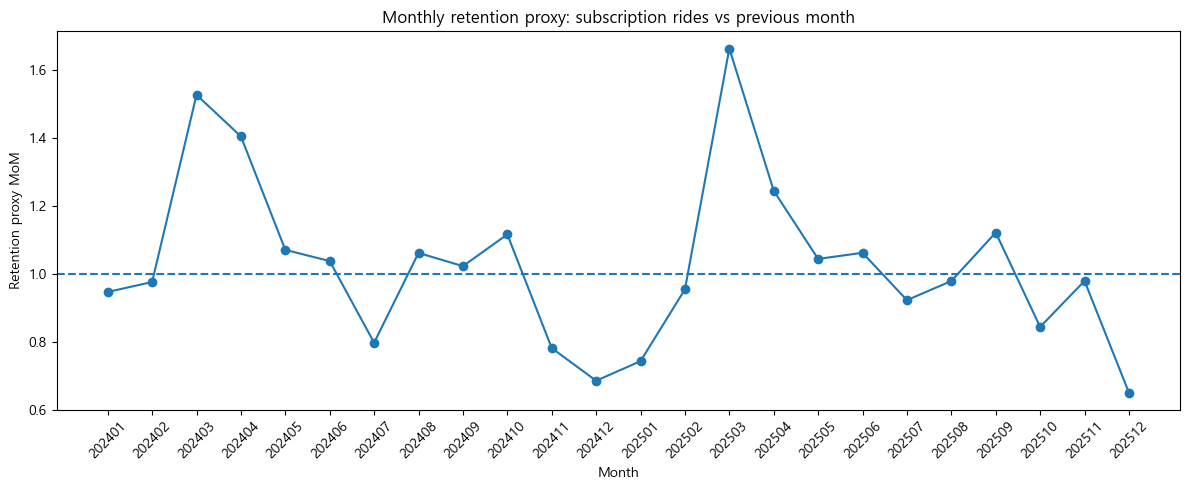

In [9]:
plot_df = monthly_retention_df.copy()
plot_df["month_label"] = plot_df["month_ym"].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(plot_df["month_label"], plot_df["retention_proxy_mom"], marker="o")
ax.axhline(1.0, linestyle="--")
ax.set_title("Monthly retention proxy: subscription rides vs previous month")
ax.set_xlabel("Month")
ax.set_ylabel("Retention proxy MoM")
ax.tick_params(axis="x", rotation=45)
save_fig("retention_01_monthly_retention_proxy_mom.png")
plt.show()

## 2. 최근 3개월 평균 대비 이번 달 정기권 이용

전월 하나만 보면 계절 변동이나 일시적 급등락의 영향을 크게 받을 수 있다.  
따라서 이번 달 정기권 이용건수가 직전 3개월 평균보다 높은지 비교한다.

- `current_vs_prev3m_avg > 1`: 최근 3개월 평균보다 이번 달 이용이 강함
- `current_vs_prev3m_avg < 1`: 최근 3개월 평균보다 이번 달 이용이 약함

In [10]:
monthly_prev3m_sql = r"""
-- 2) 최근 3개월 평균 대비 이번 달 정기권 이용
-- prev_3m_avg_sub_ride_cnt는 이번 달을 제외한 직전 3개월 평균이다.
WITH duration AS(
    SELECT month_ym, month_date, gender, age_band, sub_ride_cnt, total_ride_cnt
    FROM mart_growth_month
    UNION ALL
    SELECT 
        month_ym, month_date, gender, age_band, 
        SUM(CASE WHEN pass_group = 'SUBSCRIPTION' THEN ride_cnt ELSE 0 END) AS sub_ride_cnt,
        SUM(ride_cnt) AS total_ride_cnt
    FROM stg_ride_month
    WHERE month_ym BETWEEN 202310 AND 202312
    GROUP BY month_ym, month_date, gender, age_band
),
monthly AS (
    SELECT
        month_ym,
        month_date,
        SUM(sub_ride_cnt) AS sub_ride_cnt,
        SUM(total_ride_cnt) AS total_ride_cnt
    FROM duration
    WHERE LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY
        month_ym,
        month_date
),
windowed AS (
    SELECT
        month_ym,
        month_date,
        sub_ride_cnt,
        total_ride_cnt,
        AVG(sub_ride_cnt) OVER (
            ORDER BY month_ym
            ROWS BETWEEN 3 PRECEDING AND 1 PRECEDING
        ) AS prev_3m_avg_sub_ride_cnt
    FROM monthly
)
SELECT
    month_ym,
    month_date,
    sub_ride_cnt,
    total_ride_cnt,
    ROUND(prev_3m_avg_sub_ride_cnt, 2) AS prev_3m_avg_sub_ride_cnt,
    ROUND(
        CASE
            WHEN prev_3m_avg_sub_ride_cnt > 0
            THEN 1.0 * sub_ride_cnt / prev_3m_avg_sub_ride_cnt
            ELSE NULL
        END,
        4
    ) AS rolling_3m_persistence,
    ROUND(
        CASE
            WHEN prev_3m_avg_sub_ride_cnt > 0
            THEN 1.0 * (sub_ride_cnt - prev_3m_avg_sub_ride_cnt) / prev_3m_avg_sub_ride_cnt
            ELSE NULL
        END,
        4
    ) AS current_vs_prev3m_growth_rate
FROM windowed
WHERE month_ym BETWEEN 202401 AND 202512
ORDER BY month_ym;
"""

monthly_prev3m_df = read_sql(monthly_prev3m_sql)
monthly_prev3m_df

,month_ym,month_date,sub_ride_cnt,total_ride_cnt,prev_3m_avg_sub_ride_cnt,rolling_3m_persistence,current_vs_prev3m_growth_rate
0,202401,2024-01-01,1263464,1415117,2184791.67,0.5783,-0.4217
1,202402,2024-02-01,1232507,1449898,1588131.67,0.7761,-0.2239
2,202403,2024-03-01,1881024,2263525,1277087.00,1.4729,0.4729
3,202404,2024-04-01,2640480,3300568,1458998.33,1.8098,0.8098
4,202405,2024-05-01,2825419,3464252,1918003.67,1.4731,0.4731
5,202406,2024-06-01,2930340,3534196,2448974.33,1.1966,0.1966
6,202407,2024-07-01,2335090,2724484,2798746.33,0.8343,-0.1657
7,202408,2024-08-01,2477548,2922463,2696949.67,0.9186,-0.0814
8,202409,2024-09-01,2532283,3101004,2580992.67,0.9811,-0.0189
9,202410,2024-10-01,2824868,3440290,2448307.00,1.1538,0.1538


saved: c:\Users\위동국\Documents\GitHub\seoul-bike-aarrr-analysis\images\retention\retention_02_monthly_rolling_3m_persistence.png


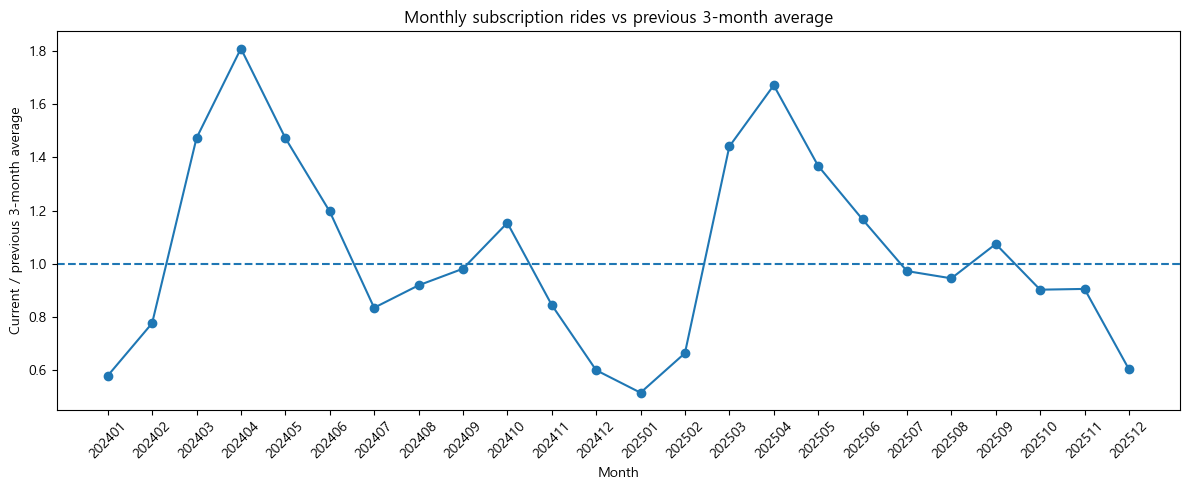

In [11]:
plot_df = monthly_prev3m_df.copy()
plot_df["month_label"] = plot_df["month_ym"].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(plot_df["month_label"], plot_df["rolling_3m_persistence"], marker="o")
ax.axhline(1.0, linestyle="--")
ax.set_title("Monthly subscription rides vs previous 3-month average")
ax.set_xlabel("Month")
ax.set_ylabel("Current / previous 3-month average")
ax.tick_params(axis="x", rotation=45)
save_fig("retention_02_monthly_rolling_3m_persistence.png")
plt.show()

saved: c:\Users\위동국\Documents\GitHub\seoul-bike-aarrr-analysis\images\retention\retention_02_monthly_retention_proxy_comparison.png


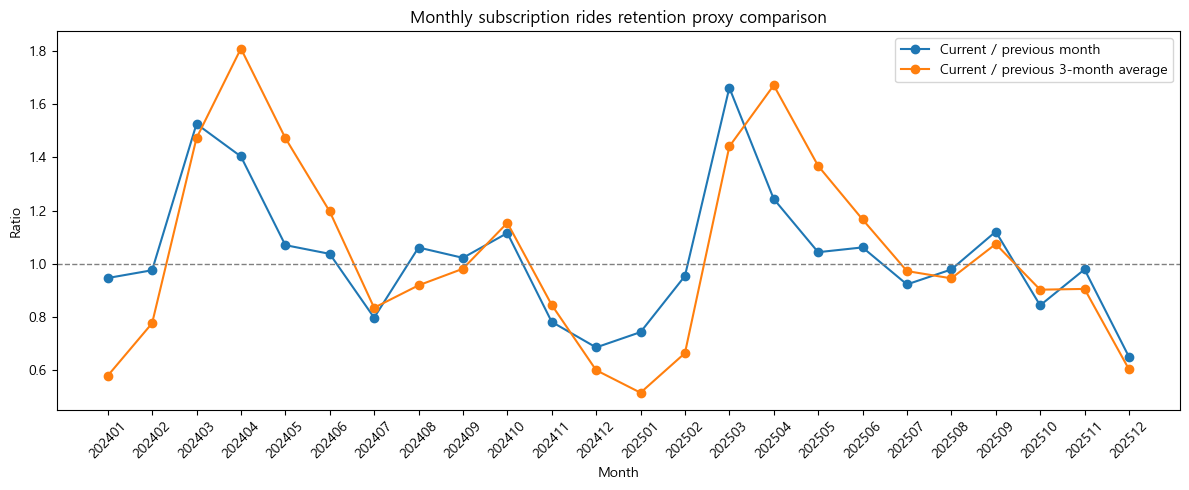

In [12]:
plot_df = monthly_retention_df[["month_ym", "retention_proxy_mom"]].merge(
    monthly_prev3m_df[["month_ym", "rolling_3m_persistence"]],
    on="month_ym",
    how="inner",
)
plot_df["month_label"] = plot_df["month_ym"].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    plot_df["month_label"],
    plot_df["retention_proxy_mom"],
    marker="o",
    label="Current / previous month",
)
ax.plot(
    plot_df["month_label"],
    plot_df["rolling_3m_persistence"],
    marker="o",
    label="Current / previous 3-month average",
)
ax.axhline(1.0, linestyle="--", color="gray", linewidth=1)
ax.set_title("Monthly subscription rides retention proxy comparison")
ax.set_xlabel("Month")
ax.set_ylabel("Ratio")
ax.tick_params(axis="x", rotation=45)
ax.legend()
save_fig("retention_02_monthly_retention_proxy_comparison.png")
plt.show()

saved: c:\Users\위동국\Documents\GitHub\seoul-bike-aarrr-analysis\images\retention\retention_03_monthly_sub_ride_vs_prev3m_avg.png


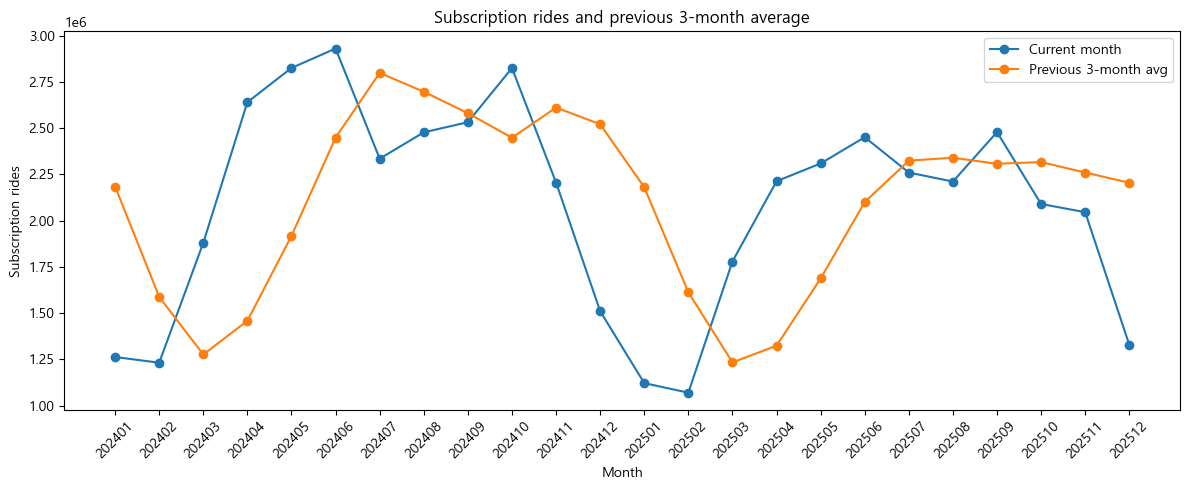

In [13]:
# 정기권 이용건수와 직전 3개월 평균을 함께 시각화
plot_df = monthly_prev3m_df.copy()
plot_df["month_label"] = plot_df["month_ym"].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(plot_df["month_label"], plot_df["sub_ride_cnt"], marker="o", label="Current month")
ax.plot(plot_df["month_label"], plot_df["prev_3m_avg_sub_ride_cnt"], marker="o", label="Previous 3-month avg")
ax.set_title("Subscription rides and previous 3-month average")
ax.set_xlabel("Month")
ax.set_ylabel("Subscription rides")
ax.tick_params(axis="x", rotation=45)
ax.legend()
save_fig("retention_03_monthly_sub_ride_vs_prev3m_avg.png")
plt.show()

## 3. 성별·연령대별 지속이용 차이

세그먼트별로 정기권 이용이 일회성 상승인지, 지속적으로 유지되는지를 비교한다.  
세그먼트 해석에서는 나이 미입력 집단인 `age_band = '기타'`를 제외한다.

In [14]:
segment_month_sql = r"""
-- 3) 성별/연령대/월별 지속이용 proxy
-- 세그먼트 해석에서는 age_band='기타'를 제외한다.
WITH duration AS(
    SELECT month_ym, month_date, gender, age_band, sub_ride_cnt, total_ride_cnt
    FROM mart_growth_month
    UNION ALL
    SELECT 
        month_ym, month_date, gender, age_band, 
        SUM(CASE WHEN pass_group = 'SUBSCRIPTION' THEN ride_cnt ELSE 0 END) AS sub_ride_cnt,
        SUM(ride_cnt) AS total_ride_cnt
    FROM stg_ride_month
    WHERE month_ym BETWEEN 202310 AND 202312
    GROUP BY month_ym, month_date, gender, age_band
),
segment_month AS (
    SELECT
        month_ym,
        month_date,
        gender,
        age_band,
        SUM(sub_ride_cnt) AS sub_ride_cnt,
        SUM(total_ride_cnt) AS total_ride_cnt
    FROM duration
    WHERE age_band <> '기타'
      AND LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY
        month_ym,
        month_date,
        gender,
        age_band
),
windowed AS (
    SELECT
        month_ym,
        month_date,
        gender,
        age_band,
        sub_ride_cnt,
        total_ride_cnt,
        LAG(sub_ride_cnt) OVER (
            PARTITION BY gender, age_band
            ORDER BY month_ym
        ) AS prev_month_sub_ride_cnt,
        AVG(sub_ride_cnt) OVER (
            PARTITION BY gender, age_band
            ORDER BY month_ym
            ROWS BETWEEN 3 PRECEDING AND 1 PRECEDING
        ) AS prev_3m_avg_sub_ride_cnt
    FROM segment_month
)
SELECT
    month_ym,
    month_date,
    gender,
    age_band,
    sub_ride_cnt,
    total_ride_cnt,
    prev_month_sub_ride_cnt,
    ROUND(
        CASE
            WHEN prev_month_sub_ride_cnt > 0
            THEN 1.0 * sub_ride_cnt / prev_month_sub_ride_cnt
            ELSE NULL
        END,
        4
    ) AS retention_proxy_mom,
    ROUND(prev_3m_avg_sub_ride_cnt, 2) AS prev_3m_avg_sub_ride_cnt,
    ROUND(
        CASE
            WHEN prev_3m_avg_sub_ride_cnt > 0
            THEN 1.0 * sub_ride_cnt / prev_3m_avg_sub_ride_cnt
            ELSE NULL
        END,
        4
    ) AS rolling_3m_persistence,
    ROUND(
        CASE
            WHEN total_ride_cnt > 0
            THEN 1.0 * sub_ride_cnt / total_ride_cnt
            ELSE NULL
        END,
        4
    ) AS same_segment_month_subscription_share
FROM windowed
WHERE month_ym BETWEEN 202401 AND 202512
ORDER BY
    gender,
    age_band,
    month_ym;
"""

segment_month_df = read_sql(segment_month_sql)
segment_month_df = add_segment_label(segment_month_df)
segment_month_df

,month_ym,month_date,gender,age_band,sub_ride_cnt,total_ride_cnt,prev_month_sub_ride_cnt,retention_proxy_mom,prev_3m_avg_sub_ride_cnt,rolling_3m_persistence,same_segment_month_subscription_share,segment
0,202401,2024-01-01,F,20대,115654,138023,140150,0.8252,256919.00,0.4502,0.8379,F / 20대
1,202402,2024-02-01,F,20대,114588,149733,115654,0.9908,168549.33,0.6798,0.7653,F / 20대
2,202403,2024-03-01,F,20대,193747,264300,114588,1.6908,123464.00,1.5693,0.7331,F / 20대
3,202404,2024-04-01,F,20대,294605,426678,193747,1.5206,141329.67,2.0845,0.6905,F / 20대
4,202405,2024-05-01,F,20대,305391,422243,294605,1.0366,200980.00,1.5195,0.7233,F / 20대
...,...,...,...,...,...,...,...,...,...,...,...,...
331,202508,2025-08-01,M,~10대,117403,167338,120358,0.9754,122801.33,0.9560,0.7016,M / ~10대
332,202509,2025-09-01,M,~10대,134365,183449,117403,1.1445,123370.67,1.0891,0.7324,M / ~10대
333,202510,2025-10-01,M,~10대,113167,164381,134365,0.8422,124042.00,0.9123,0.6884,M / ~10대
334,202511,2025-11-01,M,~10대,113373,159841,113167,1.0018,121645.00,0.9320,0.7093,M / ~10대


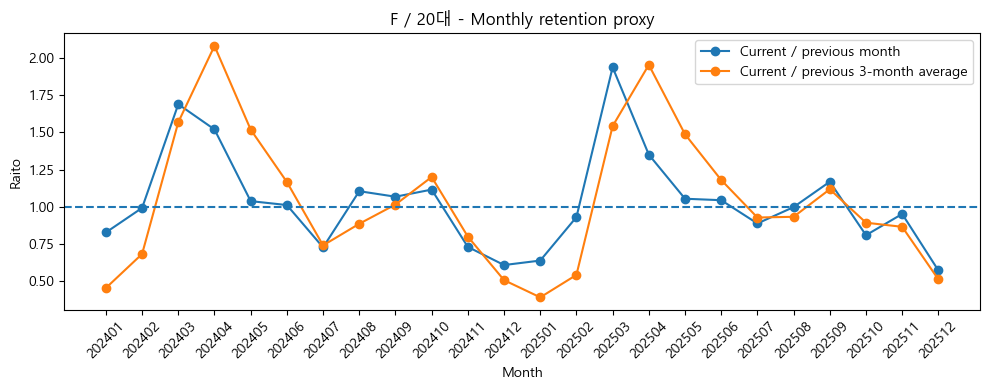

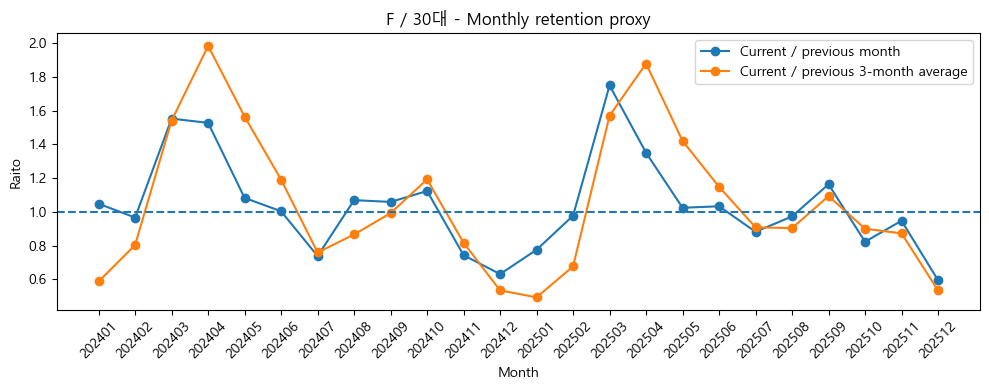

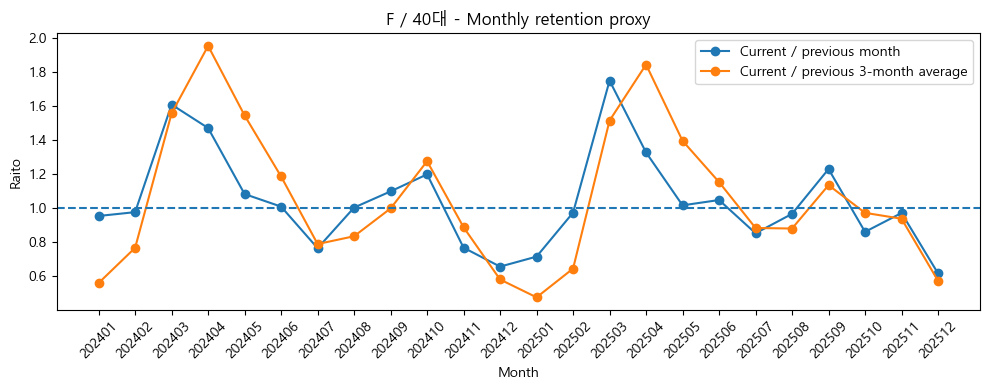

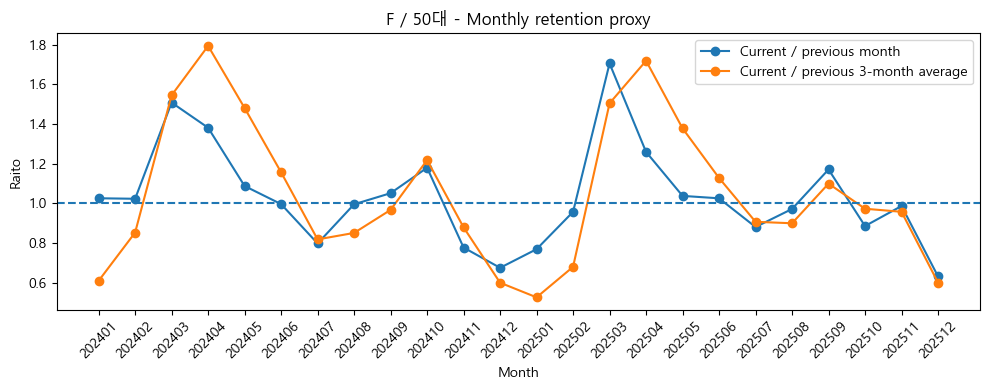

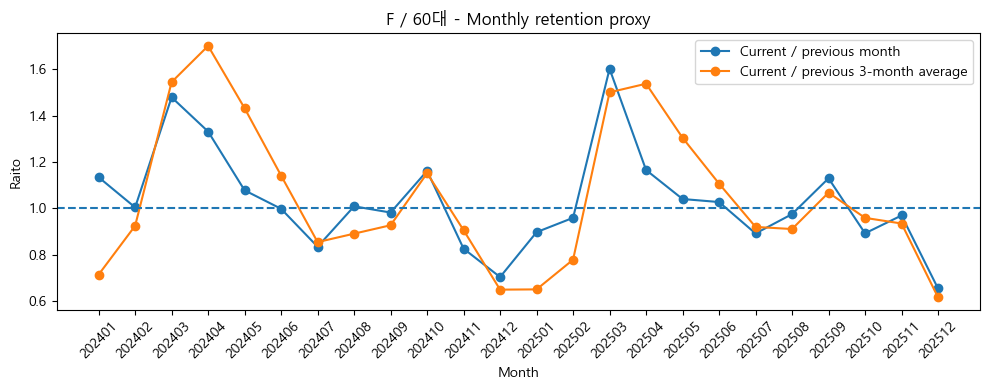

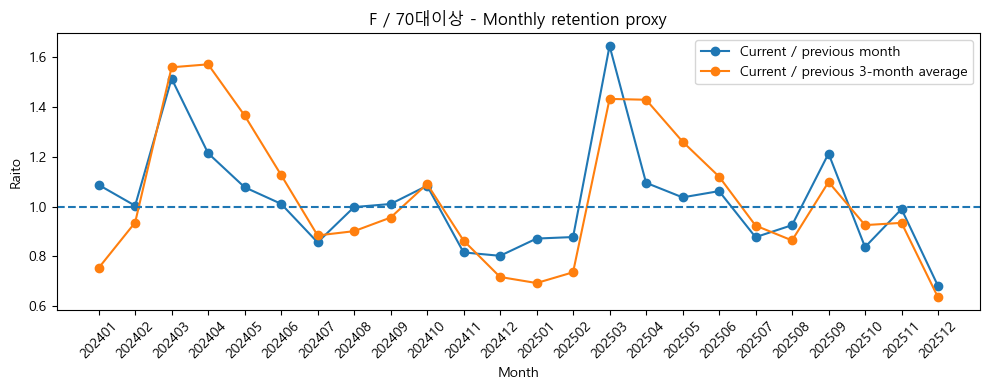

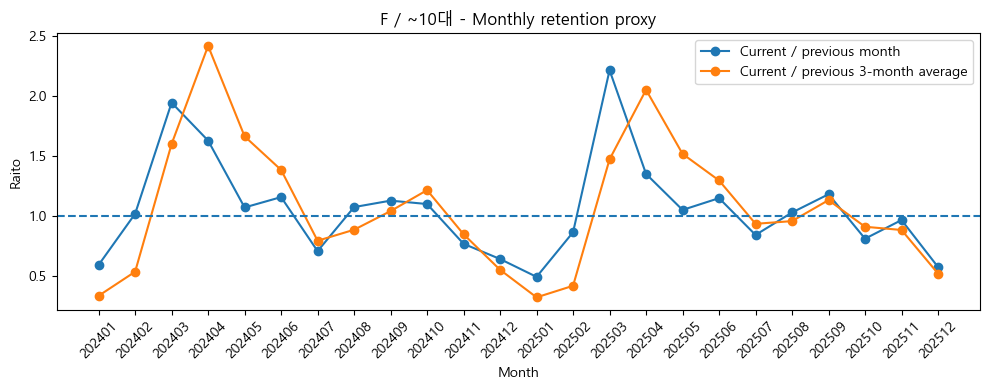

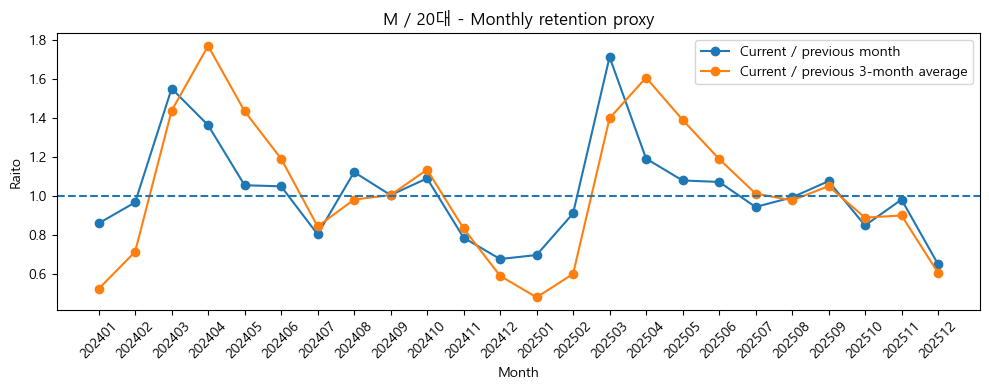

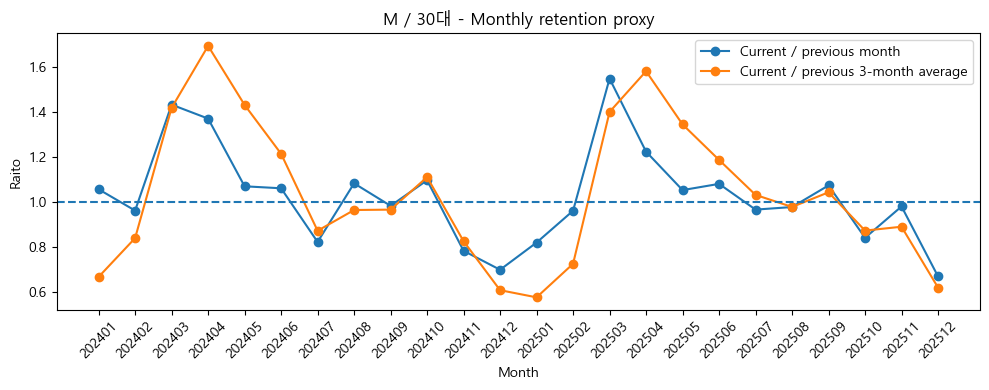

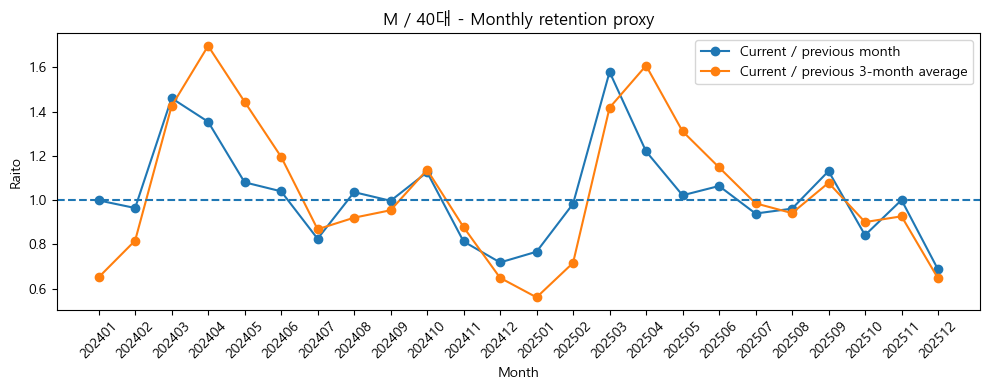

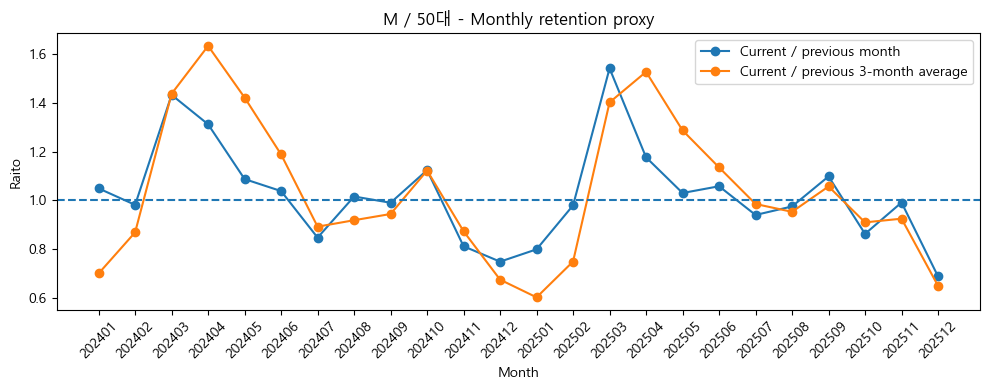

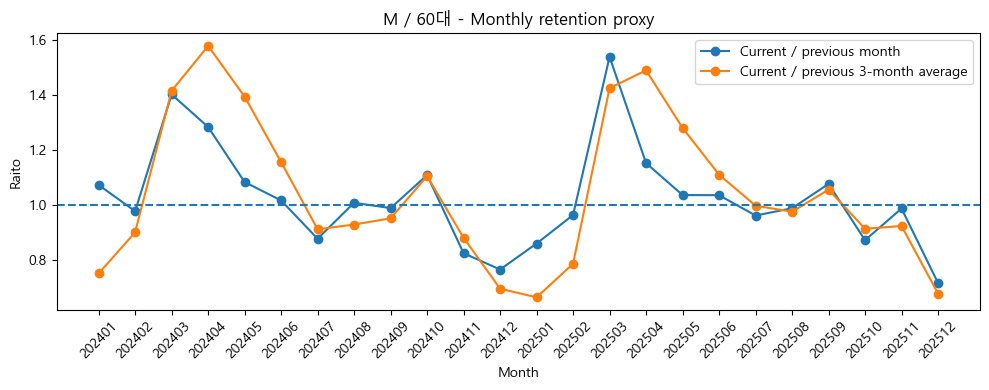

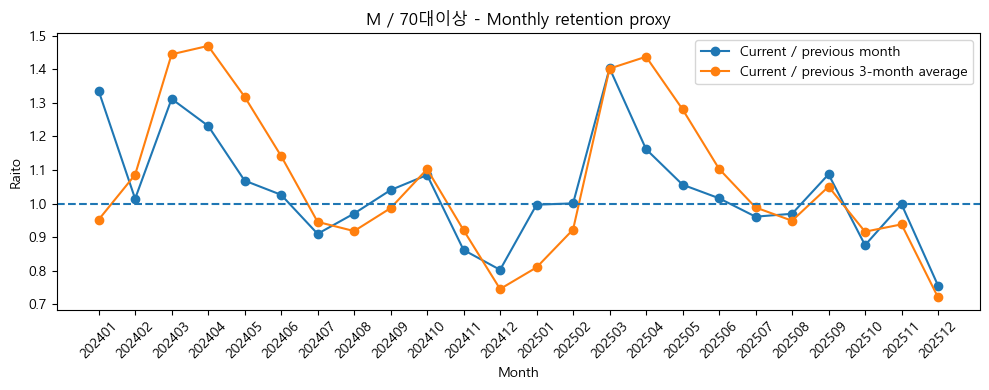

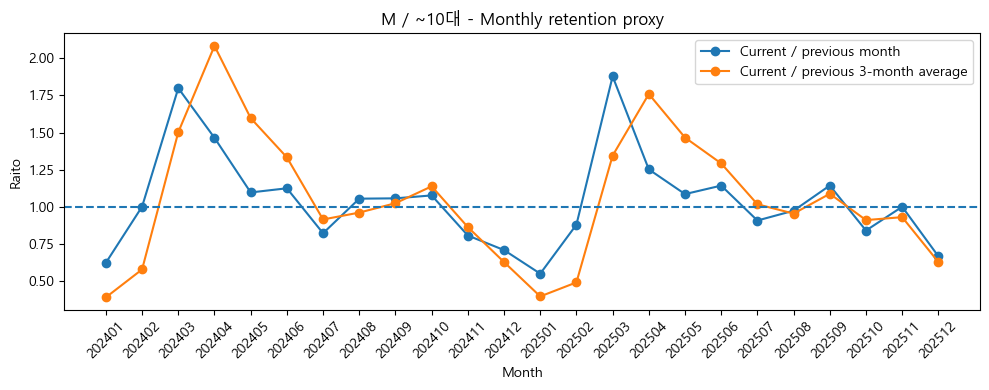

In [15]:
df = segment_month_df.copy()
df["month_label"] = df["month_ym"].astype(str)

segments = df["segment"].unique()

for seg in segments:
    temp = df[df["segment"] == seg]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(temp["month_label"], temp["retention_proxy_mom"], marker="o", label="Current / previous month")
    ax.plot(temp["month_label"], temp["rolling_3m_persistence"], marker="o", label="Current / previous 3-month average")
    ax.axhline(1.0, linestyle="--")
    ax.set_title(f"{seg} - Monthly retention proxy")
    ax.set_xlabel("Month")
    ax.set_ylabel("Raito")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.legend()
    plt.show()

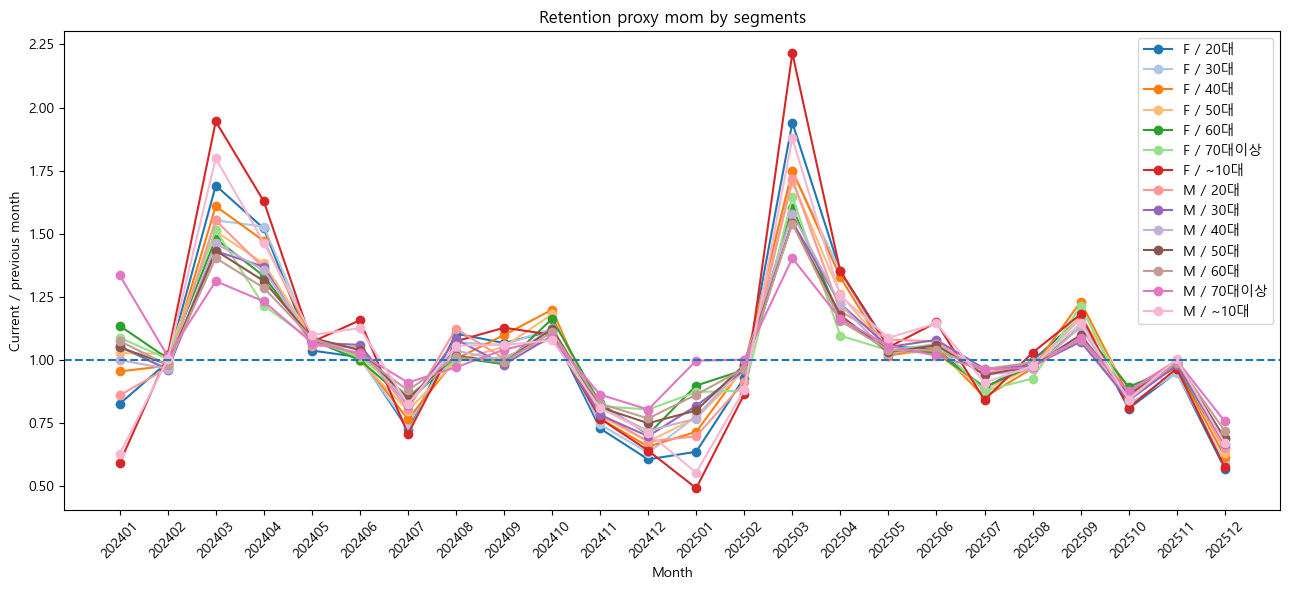

In [16]:
df = segment_month_df.copy()
df["month_label"] = df["month_ym"].astype(str)
colors = plt.cm.tab20.colors

segments = df["segment"].unique()
fig, ax = plt.subplots(figsize=(13, 6))

for i, seg in enumerate(segments):
    temp = df[df["segment"] == seg]

    ax.plot(temp["month_label"], temp["retention_proxy_mom"], marker="o", color=colors[i % len(colors)], label=seg)

ax.axhline(1.0, linestyle="--")
ax.set_title("Retention proxy mom by segments")
ax.set_xlabel("Month")
ax.set_ylabel("Current / previous month")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

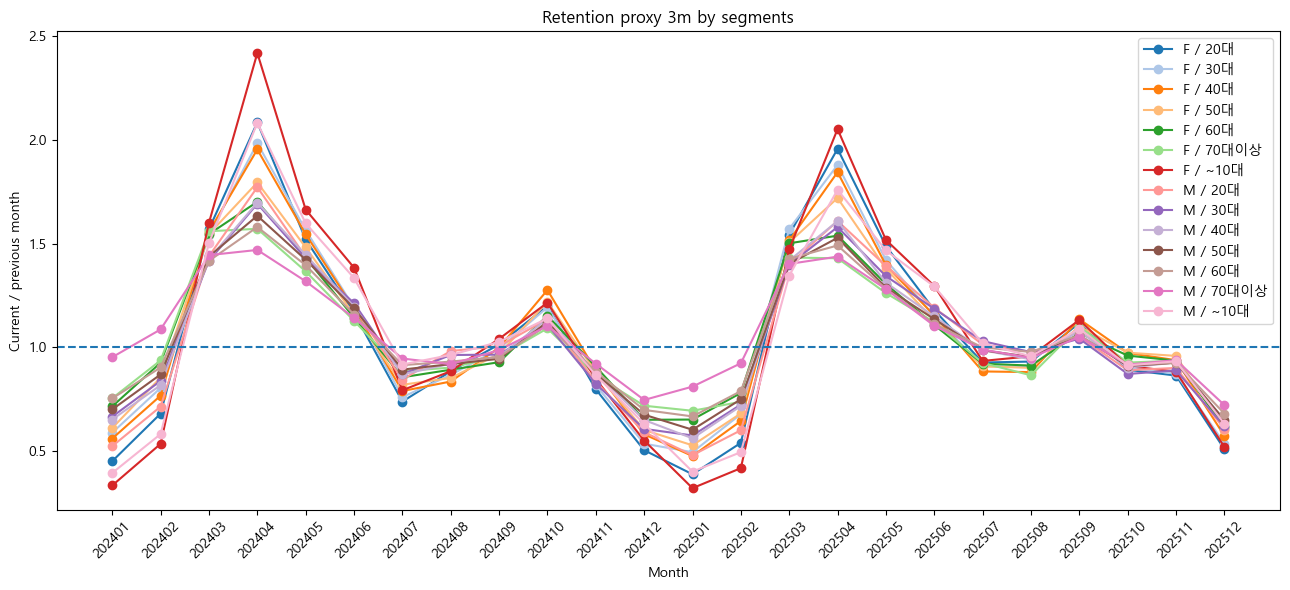

In [17]:
df = segment_month_df.copy()
df["month_label"] = df["month_ym"].astype(str)
colors = plt.cm.tab20.colors

segments = df["segment"].unique()
fig, ax = plt.subplots(figsize=(13, 6))

for i, seg in enumerate(segments):
    temp = df[df["segment"] == seg]

    ax.plot(temp["month_label"], temp["rolling_3m_persistence"], marker="o", color=colors[i % len(colors)], label=seg)

ax.axhline(1.0, linestyle="--")
ax.set_title("Retention proxy 3m by segments")
ax.set_xlabel("Month")
ax.set_ylabel("Current / previous month")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

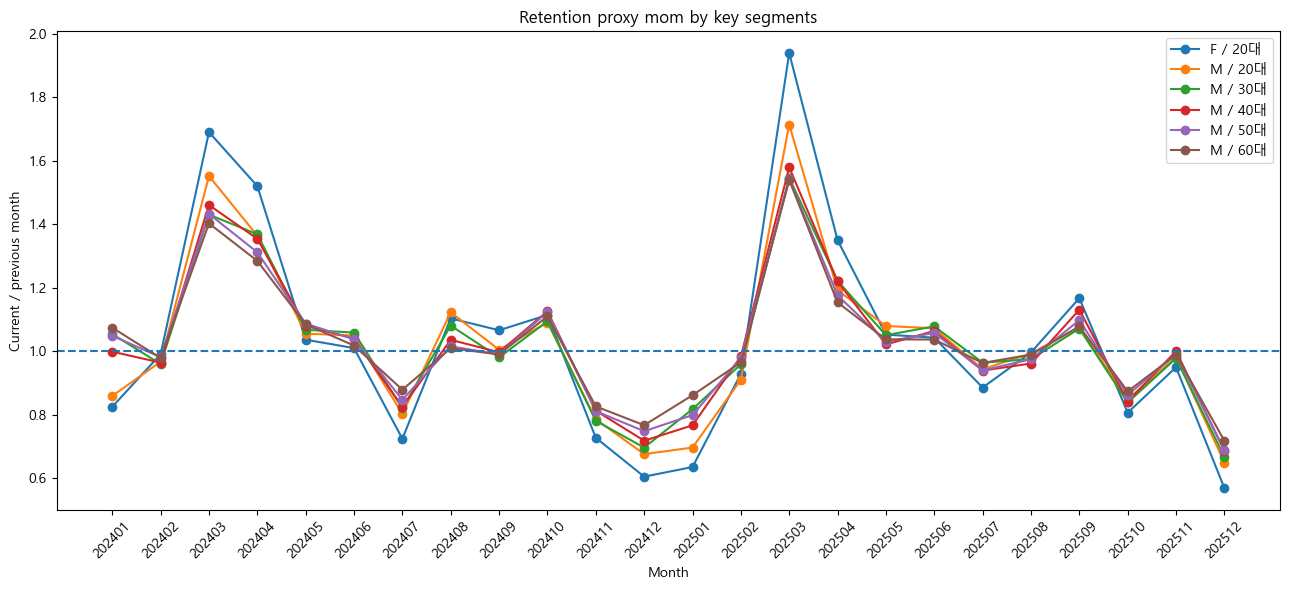

In [18]:
target_segments = ["F / 20대", "M / 20대", "M / 30대", "M / 40대", "M / 50대", "M / 60대"]

plot_df = segment_month_df[segment_month_df["segment"].isin(target_segments)].copy()
plot_df["month_label"] = plot_df["month_ym"].astype(str)

fig, ax = plt.subplots(figsize=(13, 6))

for seg in target_segments:
    temp = plot_df[plot_df["segment"] == seg]
    ax.plot(temp["month_label"], temp["retention_proxy_mom"], marker="o", label=seg)

ax.axhline(1.0, linestyle="--")
ax.set_title("Retention proxy mom by key segments")
ax.set_xlabel("Month")
ax.set_ylabel("Current / previous month")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

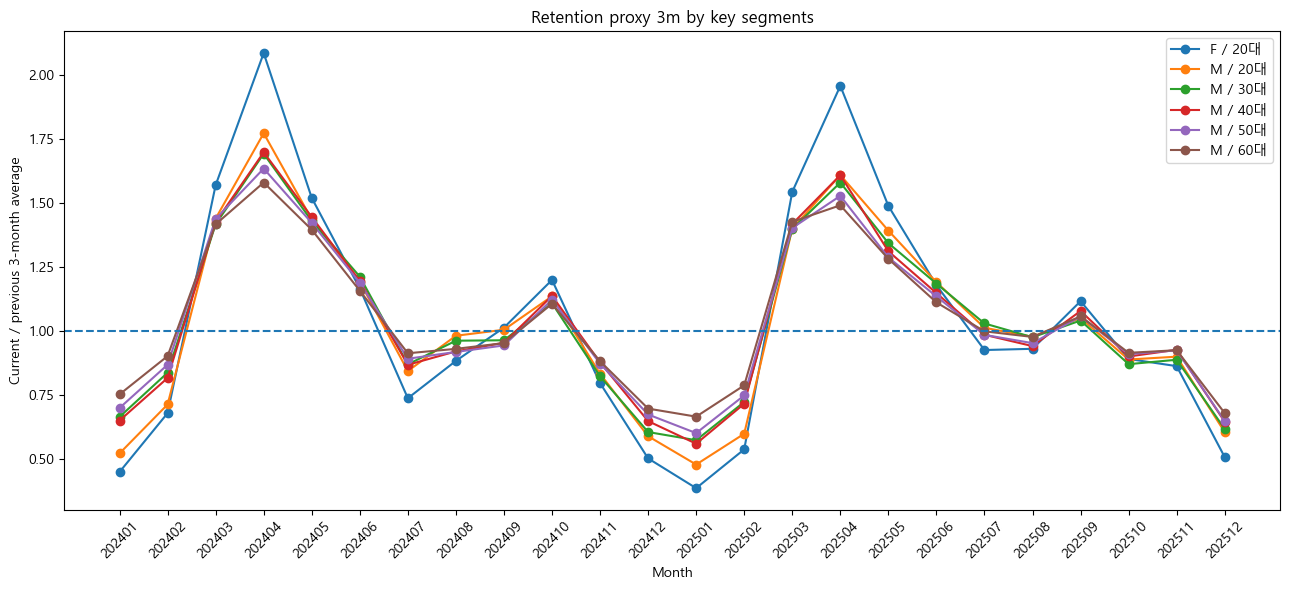

In [19]:
target_segments = ["F / 20대", "M / 20대", "M / 30대", "M / 40대", "M / 50대", "M / 60대"]

plot_df = segment_month_df[segment_month_df["segment"].isin(target_segments)].copy()
plot_df["month_label"] = plot_df["month_ym"].astype(str)

fig, ax = plt.subplots(figsize=(13, 6))

for seg in target_segments:
    temp = plot_df[plot_df["segment"] == seg]
    ax.plot(temp["month_label"], temp["rolling_3m_persistence"], marker="o", label=seg)

ax.axhline(1.0, linestyle="--")
ax.set_title("Retention proxy 3m by key segments")
ax.set_xlabel("Month")
ax.set_ylabel("Current / previous 3-month average")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

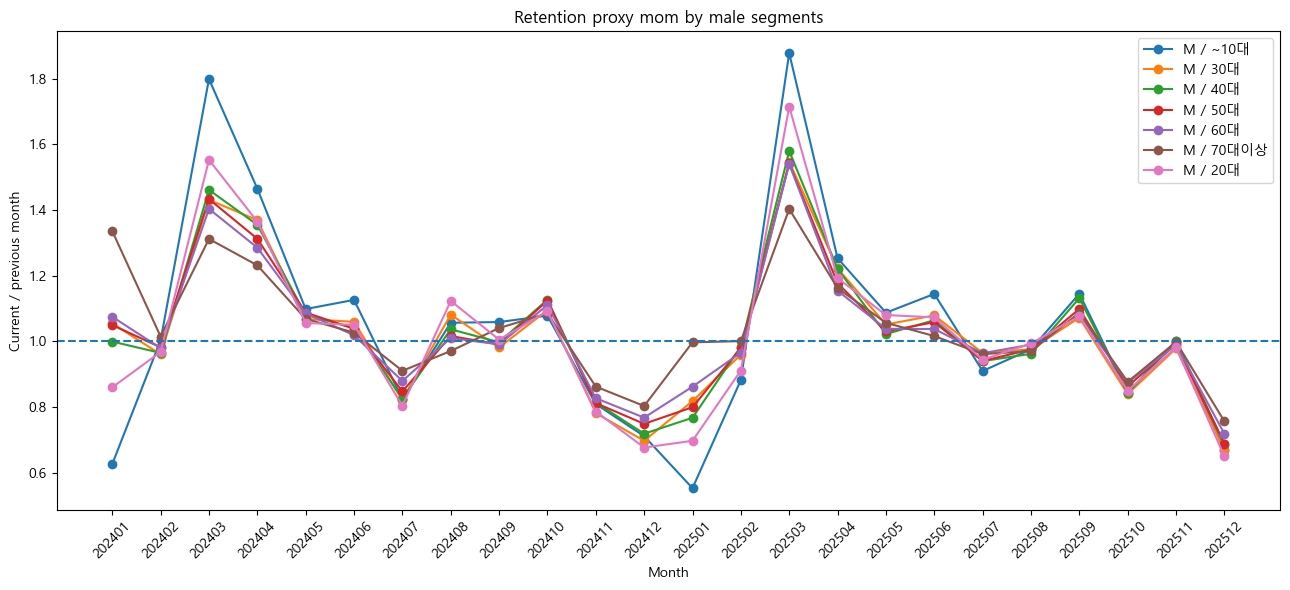

In [20]:
target_segments = ["M / ~10대", "M / 30대", "M / 40대", "M / 50대", "M / 60대", "M / 70대이상", "M / 20대"]

plot_df = segment_month_df[segment_month_df["segment"].isin(target_segments)].copy()
plot_df["month_label"] = plot_df["month_ym"].astype(str)

fig, ax = plt.subplots(figsize=(13, 6))

for seg in target_segments:
    temp = plot_df[plot_df["segment"] == seg]
    ax.plot(temp["month_label"], temp["retention_proxy_mom"], marker="o", label=seg)

ax.axhline(1.0, linestyle="--")
ax.set_title("Retention proxy mom by male segments")
ax.set_xlabel("Month")
ax.set_ylabel("Current / previous month")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

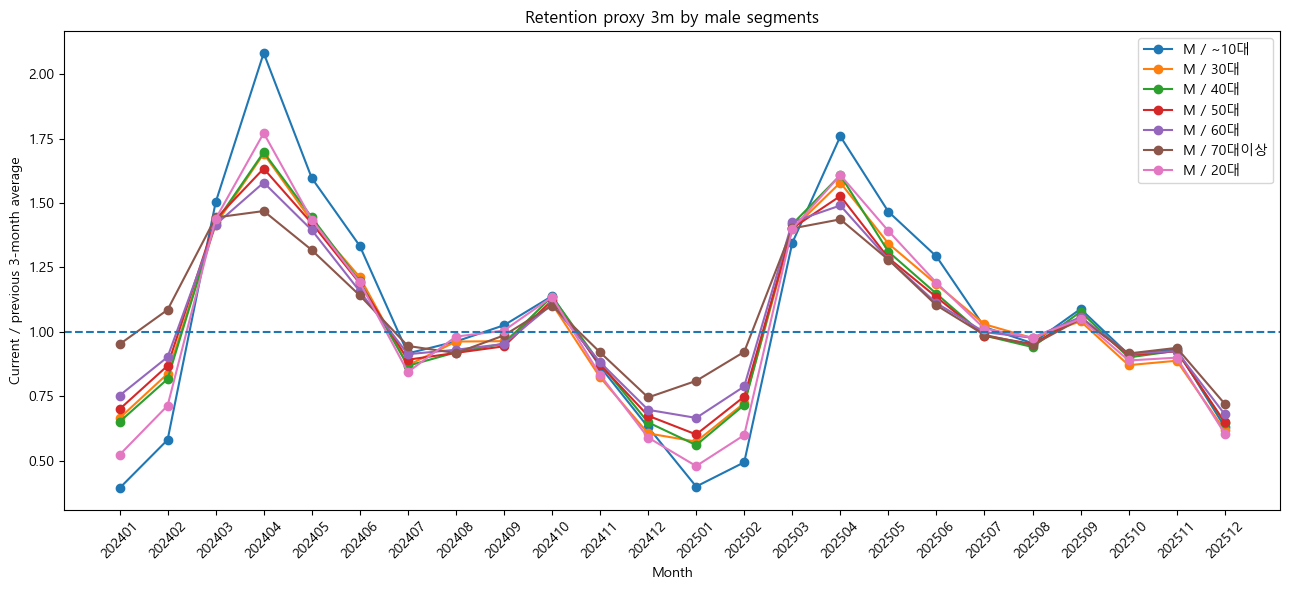

In [21]:
target_segments = ["M / ~10대", "M / 30대", "M / 40대", "M / 50대", "M / 60대", "M / 70대이상", "M / 20대"]

plot_df = segment_month_df[segment_month_df["segment"].isin(target_segments)].copy()
plot_df["month_label"] = plot_df["month_ym"].astype(str)

fig, ax = plt.subplots(figsize=(13, 6))

for seg in target_segments:
    temp = plot_df[plot_df["segment"] == seg]
    ax.plot(temp["month_label"], temp["rolling_3m_persistence"], marker="o", label=seg)

ax.axhline(1.0, linestyle="--")
ax.set_title("Retention proxy 3m by male segments")
ax.set_xlabel("Month")
ax.set_ylabel("Current / previous 3-month average")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

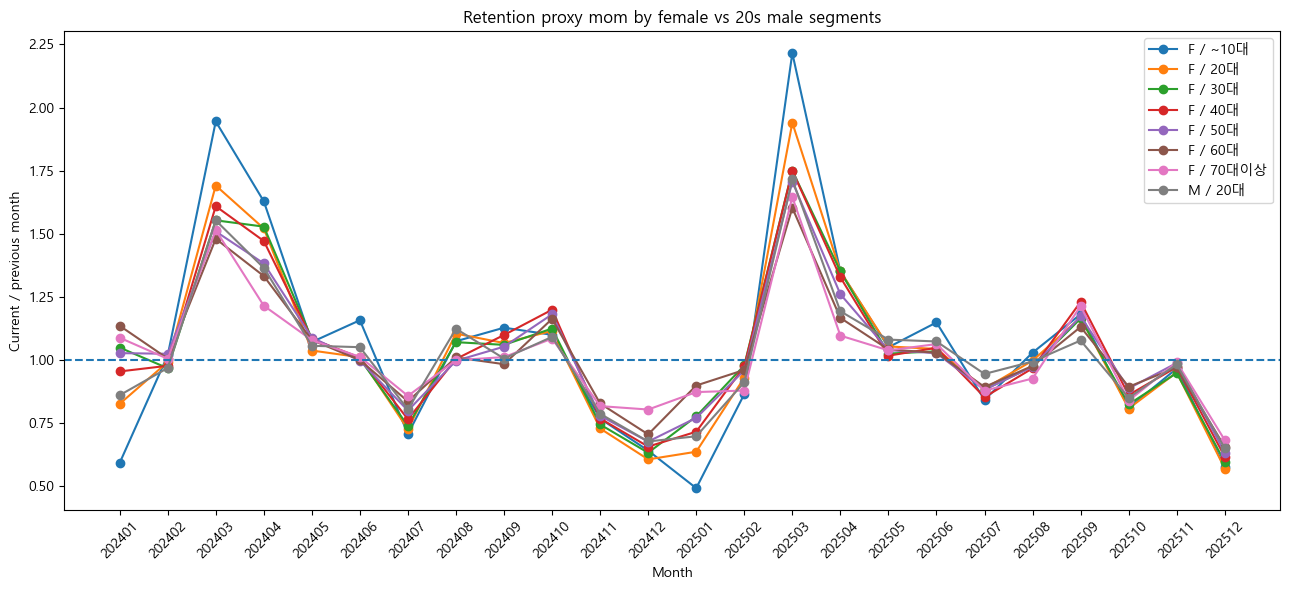

In [22]:
target_segments = ["F / ~10대", "F / 20대", "F / 30대", "F / 40대", "F / 50대", "F / 60대", "F / 70대이상", "M / 20대"]

plot_df = segment_month_df[segment_month_df["segment"].isin(target_segments)].copy()
plot_df["month_label"] = plot_df["month_ym"].astype(str)

fig, ax = plt.subplots(figsize=(13, 6))

for seg in target_segments:
    temp = plot_df[plot_df["segment"] == seg]
    ax.plot(temp["month_label"], temp["retention_proxy_mom"], marker="o", label=seg)

ax.axhline(1.0, linestyle="--")
ax.set_title("Retention proxy mom by female vs 20s male segments")
ax.set_xlabel("Month")
ax.set_ylabel("Current / previous month")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

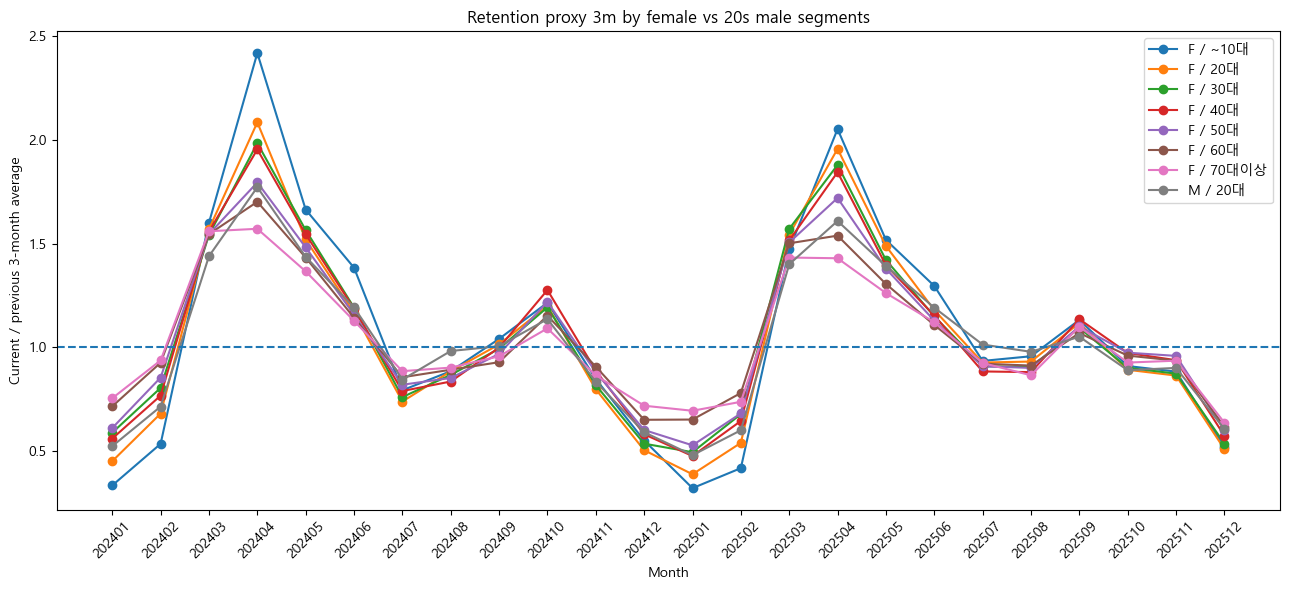

In [23]:
target_segments = ["F / ~10대", "F / 20대", "F / 30대", "F / 40대", "F / 50대", "F / 60대", "F / 70대이상", "M / 20대"]

plot_df = segment_month_df[segment_month_df["segment"].isin(target_segments)].copy()
plot_df["month_label"] = plot_df["month_ym"].astype(str)

fig, ax = plt.subplots(figsize=(13, 6))

for seg in target_segments:
    temp = plot_df[plot_df["segment"] == seg]
    ax.plot(temp["month_label"], temp["rolling_3m_persistence"], marker="o", label=seg)

ax.axhline(1.0, linestyle="--")
ax.set_title("Retention proxy 3m by female vs 20s male segments")
ax.set_xlabel("Month")
ax.set_ylabel("Current / previous 3-month average")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

In [24]:
male_20s_segment_sql = r"""
--4) 월별 전체 평균 대비 남성 20대 세그먼트 상대 지표
WITH base AS (
    SELECT
        month_ym,
        gender,
        age_band,
        retention_proxy_mom,
        rolling_3m_persistence
    FROM mart_growth_month
    WHERE age_band <> '기타'
      AND LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
),
monthly_avg AS (
    SELECT
        month_ym,
        AVG(retention_proxy_mom) AS avg_retention_proxy_mom,
        AVG(rolling_3m_persistence) AS avg_rolling_3m_persistence
    FROM base
    GROUP BY month_ym
)
SELECT
    b.month_ym,
    b.gender,
    b.age_band,
    b.retention_proxy_mom,
    b.rolling_3m_persistence,
    ROUND(b.retention_proxy_mom - m.avg_retention_proxy_mom, 4) AS mom_gap_from_month_avg,
    ROUND(b.rolling_3m_persistence - m.avg_rolling_3m_persistence, 4) AS rolling_3m_gap_from_month_avg
FROM base b
JOIN monthly_avg m
    ON b.month_ym = m.month_ym
WHERE b.gender = 'M'
  AND b.age_band = '20대'
ORDER BY b.month_ym;
"""

male_20s_segment_df = read_sql(male_20s_segment_sql)
male_20s_segment_df

,month_ym,gender,age_band,retention_proxy_mom,rolling_3m_persistence,mom_gap_from_month_avg,rolling_3m_gap_from_month_avg
0,202401,M,20대,0.859528,0.522740,-0.1165,-0.0948
1,202402,M,20대,0.967269,0.713610,-0.0222,-0.0939
2,202403,M,20대,1.552419,1.438919,0.0032,-0.0612
3,202404,M,20대,1.364247,1.771665,-0.0255,-0.0450
4,202405,M,20대,1.055458,1.435883,-0.0202,-0.0366
5,202406,M,20대,1.049856,1.192139,0.0111,-0.0060
6,202407,M,20대,0.803130,0.843927,-0.0063,-0.0051
7,202408,M,20대,1.122832,0.981746,0.0839,0.0740
8,202409,M,20대,1.004891,1.005051,-0.0278,0.0245
9,202410,M,20대,1.090849,1.135748,-0.0285,-0.0212


In [25]:
segment_summary_sql = r"""
-- 5) 성별/연령대별 지속이용 차이 요약
WITH duration AS(
    SELECT month_ym, month_date, gender, age_band, sub_ride_cnt, total_ride_cnt
    FROM mart_growth_month
    UNION ALL
    SELECT 
        month_ym, month_date, gender, age_band, 
        SUM(CASE WHEN pass_group = 'SUBSCRIPTION' THEN ride_cnt ELSE 0 END) AS sub_ride_cnt,
        SUM(ride_cnt) AS total_ride_cnt
    FROM stg_ride_month
    WHERE month_ym BETWEEN 202310 AND 202312
    GROUP BY month_ym, month_date, gender, age_band
),
segment_month AS (
    SELECT
        month_ym,
        month_date,
        gender,
        age_band,
        SUM(sub_ride_cnt) AS sub_ride_cnt,
        SUM(total_ride_cnt) AS total_ride_cnt
    FROM duration
    WHERE age_band <> '기타'
      AND LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY
        month_ym,
        month_date,
        gender,
        age_band
),
windowed AS (
    SELECT
        month_ym,
        month_date,
        gender,
        age_band,
        sub_ride_cnt,
        total_ride_cnt,
        LAG(sub_ride_cnt) OVER (
            PARTITION BY gender, age_band
            ORDER BY month_ym
        ) AS prev_month_sub_ride_cnt,
        AVG(sub_ride_cnt) OVER (
            PARTITION BY gender, age_band
            ORDER BY month_ym
            ROWS BETWEEN 3 PRECEDING AND 1 PRECEDING
        ) AS prev_3m_avg_sub_ride_cnt
    FROM segment_month
),
metrics AS (
    SELECT
        month_ym,
        month_date,
        gender,
        age_band,
        sub_ride_cnt,
        total_ride_cnt,
        CASE
            WHEN prev_month_sub_ride_cnt > 0
            THEN 1.0 * sub_ride_cnt / prev_month_sub_ride_cnt
            ELSE NULL
        END AS retention_proxy_mom,
        CASE
            WHEN prev_3m_avg_sub_ride_cnt > 0
            THEN 1.0 * sub_ride_cnt / prev_3m_avg_sub_ride_cnt
            ELSE NULL
        END AS rolling_3m_persistence,
        CASE
            WHEN total_ride_cnt > 0
            THEN 1.0 * sub_ride_cnt / total_ride_cnt
            ELSE NULL
        END AS subscription_share
    FROM windowed
    WHERE month_ym BETWEEN 202401 AND 202512
),
summary AS (
    SELECT
        gender,
        age_band,
        COUNT(*) AS active_month_count,
        SUM(sub_ride_cnt) AS total_sub_ride_cnt,
        ROUND(AVG(sub_ride_cnt), 2) AS avg_monthly_sub_ride_cnt,
        ROUND(AVG(retention_proxy_mom), 4) AS avg_retention_proxy_mom,
        ROUND(AVG(rolling_3m_persistence), 4) AS avg_rolling_3m_persistence,
        ROUND(AVG(subscription_share), 4) AS avg_subscription_share,
        ROUND(AVG(CASE WHEN retention_proxy_mom >= 1 THEN 1.0 ELSE 0.0 END), 4) AS retention_ge_1_share,
        ROUND(AVG(CASE WHEN rolling_3m_persistence >= 1 THEN 1.0 ELSE 0.0 END), 4) AS current_ge_prev3m_avg_share
    FROM metrics
    GROUP BY
        gender,
        age_band
),
ranked AS (
    SELECT
        *,
        NTILE(3) OVER (ORDER BY avg_monthly_sub_ride_cnt) AS volume_tertile,
        NTILE(3) OVER (ORDER BY avg_retention_proxy_mom) AS retention_tertile,
        NTILE(3) OVER (ORDER BY avg_rolling_3m_persistence) AS prev3m_tertile
    FROM summary
)
SELECT
    gender,
    age_band,
    active_month_count,
    total_sub_ride_cnt,
    avg_monthly_sub_ride_cnt,
    avg_retention_proxy_mom,
    avg_rolling_3m_persistence,
    avg_subscription_share,
    retention_ge_1_share,
    current_ge_prev3m_avg_share,
    volume_tertile,
    retention_tertile,
    prev3m_tertile,
    CASE
        WHEN volume_tertile = 3
         AND retention_tertile = 3
         AND prev3m_tertile = 3
        THEN '규모 큼 + 지속이용 강함'
        WHEN volume_tertile <= 2
         AND retention_tertile = 3
         AND prev3m_tertile = 3
        THEN '규모는 작지만 지속성 높음'
        WHEN volume_tertile = 3
         AND (retention_tertile = 1 OR prev3m_tertile = 1)
        THEN '규모는 크지만 지속성 약함'
        WHEN avg_subscription_share >= 0.9
        THEN '정기권 중심 지속 이용 성향'
        ELSE '일반'
    END AS retention_segment_type
FROM ranked
ORDER BY
    CASE
        WHEN volume_tertile = 3
         AND retention_tertile = 3
         AND prev3m_tertile = 3
        THEN 1
        WHEN volume_tertile <= 2
         AND retention_tertile = 3
         AND prev3m_tertile = 3
        THEN 2
        WHEN volume_tertile = 3
         AND (retention_tertile = 1 OR prev3m_tertile = 1)
        THEN 3
        WHEN avg_subscription_share >= 0.9
        THEN 4
        ELSE 5
    END,
    avg_retention_proxy_mom DESC,
    avg_rolling_3m_persistence DESC;
"""

segment_summary_df = read_sql(segment_summary_sql)
segment_summary_df = add_segment_label(segment_summary_df)
segment_summary_df

,gender,age_band,active_month_count,total_sub_ride_cnt,avg_monthly_sub_ride_cnt,avg_retention_proxy_mom,avg_rolling_3m_persistence,avg_subscription_share,retention_ge_1_share,current_ge_prev3m_avg_share,volume_tertile,retention_tertile,prev3m_tertile,retention_segment_type,segment
0,F,~10대,24,849179,35382.46,1.0557,1.0694,0.6666,0.5833,0.4583,1,3,3,규모는 작지만 지속성 높음,F / ~10대
1,M,~10대,24,2649824,110409.33,1.0413,1.0553,0.7192,0.5833,0.5000,2,3,3,규모는 작지만 지속성 높음,M / ~10대
2,M,70대이상,24,360798,15033.25,1.0390,1.0644,0.9675,0.5833,0.4583,1,3,3,규모는 작지만 지속성 높음,M / 70대이상
3,F,40대,24,3008570,125357.08,1.0380,1.0558,0.8749,0.5000,0.4167,2,3,3,규모는 작지만 지속성 높음,F / 40대
4,M,40대,24,6030368,251265.33,1.0256,1.0367,0.9078,0.5000,0.4167,3,1,1,규모는 크지만 지속성 약함,M / 40대
5,M,30대,24,8257169,344048.71,1.0236,1.0339,0.8666,0.5000,0.4583,3,1,1,규모는 크지만 지속성 약함,M / 30대
6,M,20대,24,6887715,286988.13,1.0205,1.0238,0.7779,0.5000,0.5000,3,1,1,규모는 크지만 지속성 약함,M / 20대
7,F,50대,24,2195966,91498.58,1.0331,1.0483,0.9257,0.5000,0.4167,2,2,2,정기권 중심 지속 이용 성향,F / 50대
8,F,60대,24,572595,23858.13,1.0316,1.0474,0.9475,0.5000,0.4167,1,2,2,정기권 중심 지속 이용 성향,F / 60대
9,M,60대,24,1906035,79418.13,1.0265,1.0419,0.9571,0.5000,0.4167,1,2,2,정기권 중심 지속 이용 성향,M / 60대


saved: c:\Users\위동국\Documents\GitHub\seoul-bike-aarrr-analysis\images\retention\retention_04_top_segments_by_avg_retention_proxy_mom.png


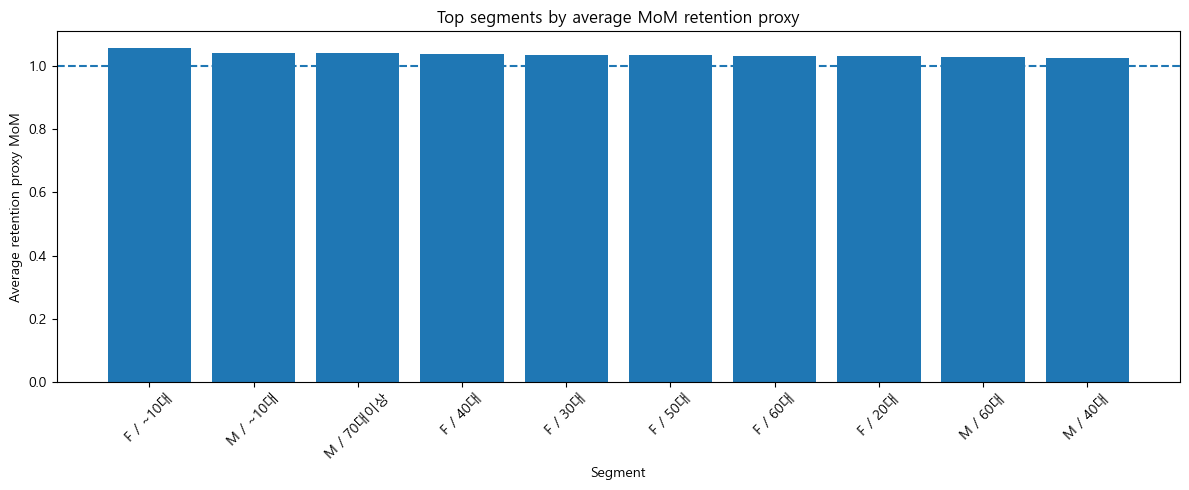

In [26]:
top_retention = segment_summary_df.sort_values("avg_retention_proxy_mom", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top_retention["segment"], top_retention["avg_retention_proxy_mom"])
ax.axhline(1.0, linestyle="--")
ax.set_title("Top segments by average MoM retention proxy")
ax.set_xlabel("Segment")
ax.set_ylabel("Average retention proxy MoM")
ax.tick_params(axis="x", rotation=45)
save_fig("retention_04_top_segments_by_avg_retention_proxy_mom.png")
plt.show()

saved: c:\Users\위동국\Documents\GitHub\seoul-bike-aarrr-analysis\images\retention\retention_05_top_segments_by_avg_rolling_3m_persistence.png


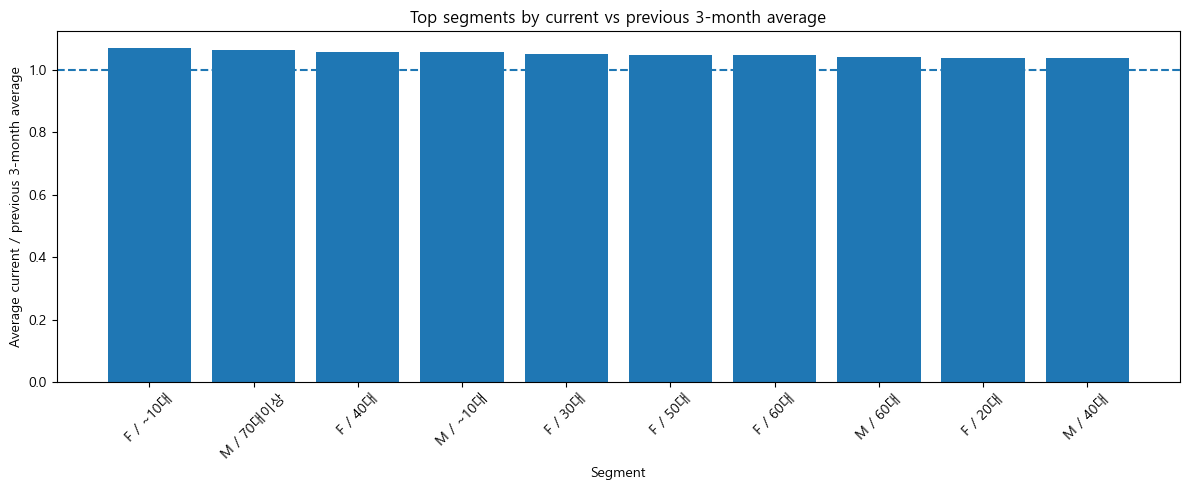

In [27]:
top_prev3m = segment_summary_df.sort_values("avg_rolling_3m_persistence", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top_prev3m["segment"], top_prev3m["avg_rolling_3m_persistence"])
ax.axhline(1.0, linestyle="--")
ax.set_title("Top segments by current vs previous 3-month average")
ax.set_xlabel("Segment")
ax.set_ylabel("Average current / previous 3-month average")
ax.tick_params(axis="x", rotation=45)
save_fig("retention_05_top_segments_by_avg_rolling_3m_persistence.png")
plt.show()

saved: c:\Users\위동국\Documents\GitHub\seoul-bike-aarrr-analysis\images\retention\retention_06_segment_volume_vs_retention_strength.png


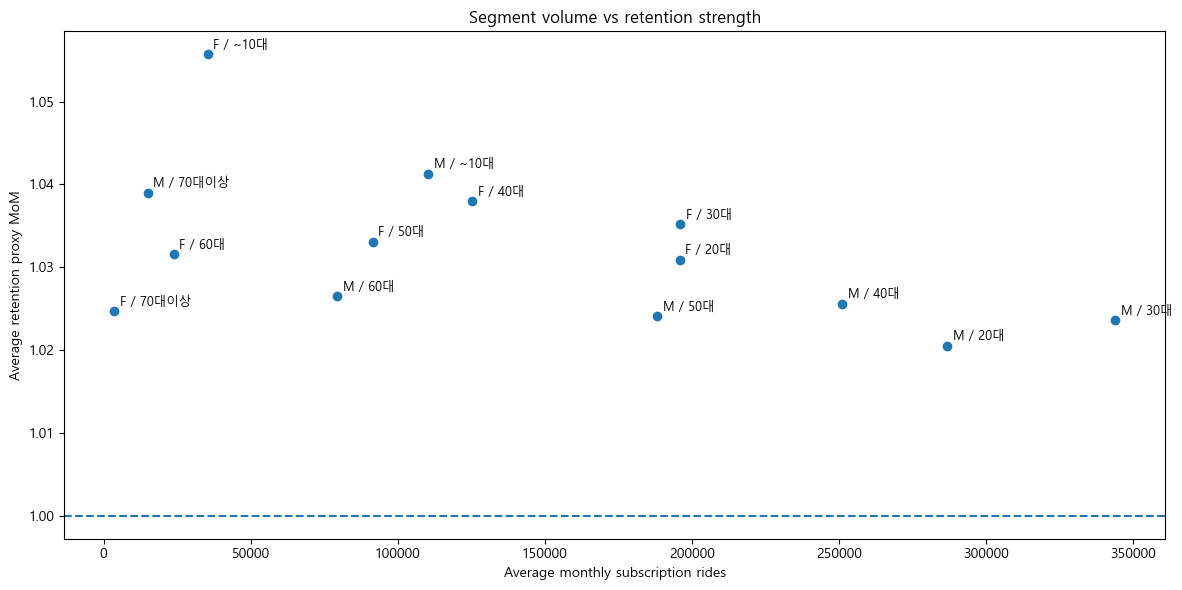

In [28]:
# 규모와 지속성의 관계
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(segment_summary_df["avg_monthly_sub_ride_cnt"], segment_summary_df["avg_retention_proxy_mom"])

for _, row in segment_summary_df.iterrows():
    ax.annotate(
        row["segment"],
        (row["avg_monthly_sub_ride_cnt"], row["avg_retention_proxy_mom"]),
        fontsize=9,
        xytext=(4, 4),
        textcoords="offset points"
    )

ax.axhline(1.0, linestyle="--")
ax.set_title("Segment volume vs retention strength")
ax.set_xlabel("Average monthly subscription rides")
ax.set_ylabel("Average retention proxy MoM")
save_fig("retention_06_segment_volume_vs_retention_strength.png")
plt.show()

saved: c:\Users\위동국\Documents\GitHub\seoul-bike-aarrr-analysis\images\retention\retention_07_retention_segment_type_count.png


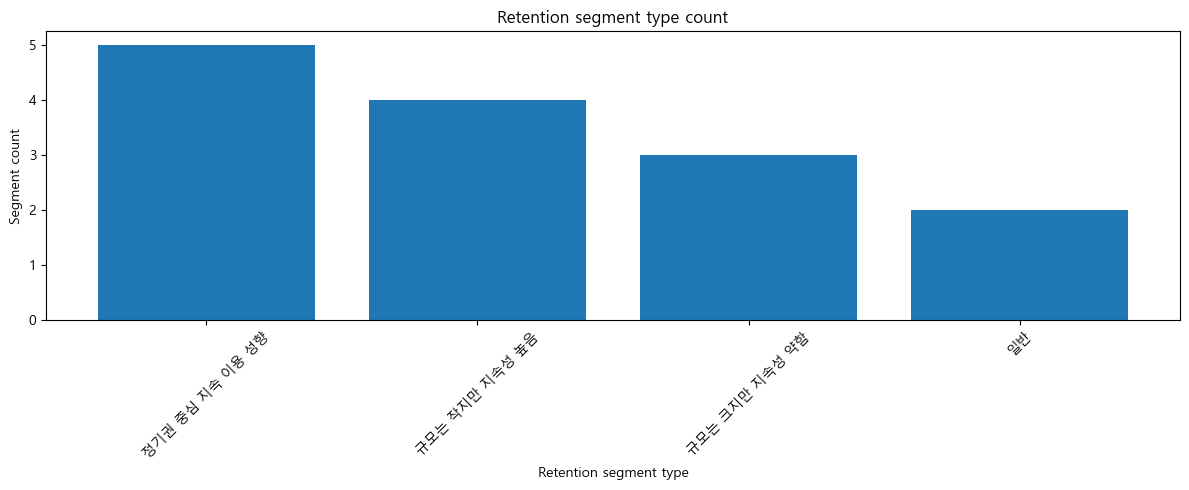

,retention_segment_type,segment_count
3,정기권 중심 지속 이용 성향,5
0,규모는 작지만 지속성 높음,4
1,규모는 크지만 지속성 약함,3
2,일반,2


In [29]:
# Retention 유형별 세그먼트 수
type_count = (
    segment_summary_df
    .groupby("retention_segment_type")
    .size()
    .reset_index(name="segment_count")
    .sort_values("segment_count", ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(type_count["retention_segment_type"], type_count["segment_count"])
ax.set_title("Retention segment type count")
ax.set_xlabel("Retention segment type")
ax.set_ylabel("Segment count")
ax.tick_params(axis="x", rotation=45)
save_fig("retention_07_retention_segment_type_count.png")
plt.show()

type_count

### 세그먼트별 해석 기준

- `규모 큼 + 지속이용 강함`: 정기권 이용 규모가 크고, 전월 대비 및 최근 3개월 평균 대비 지표가 모두 높은 핵심 Retention 세그먼트다.
- `규모는 작지만 지속성 높음`: 전체 규모는 크지 않지만 이용이 안정적으로 유지되는 고효율 세그먼트다.
- `규모는 크지만 지속성 약함`: 정기권 이용 규모는 크지만 최근 흐름 대비 유지력이 약한 개선 후보 세그먼트다.
- `정기권 중심 지속 이용 성향`: 전체 이용 중 정기권 비중이 높아 반복 이용 성격이 강한 세그먼트다.

## 4. 월별 약한 Retention 후보

월별로 정기권 이용 규모는 큰 편이지만 전월 대비 유지율이 낮은 세그먼트를 찾는다.  
이 결과에 반복적으로 등장하는 세그먼트는 정기권 이용 규모는 크지만 유지가 불안정한 후보로 볼 수 있다.

In [30]:
weak_retention_sql = r"""
-- 6) 월별 약한 Retention 후보
-- 해당 월 정기권 이용 규모는 큰 편이지만 전월 대비 유지율이 낮은 세그먼트를 찾는다.
WITH duration AS(
    SELECT month_ym, month_date, gender, age_band, sub_ride_cnt, total_ride_cnt
    FROM mart_growth_month
    UNION ALL
    SELECT 
        month_ym, month_date, gender, age_band, 
        SUM(CASE WHEN pass_group = 'SUBSCRIPTION' THEN ride_cnt ELSE 0 END) AS sub_ride_cnt,
        SUM(ride_cnt) AS total_ride_cnt
    FROM stg_ride_month
    WHERE month_ym = 202312
    GROUP BY month_ym, month_date, gender, age_band
),
segment_month AS (
    SELECT
        month_ym,
        month_date,
        gender,
        age_band,
        SUM(sub_ride_cnt) AS sub_ride_cnt,
        SUM(total_ride_cnt) AS total_ride_cnt
    FROM duration
    WHERE age_band <> '기타'
      AND LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY
        month_ym,
        month_date,
        gender,
        age_band
),
windowed AS (
    SELECT
        month_ym,
        month_date,
        gender,
        age_band,
        sub_ride_cnt,
        total_ride_cnt,
        LAG(sub_ride_cnt) OVER (
            PARTITION BY gender, age_band
            ORDER BY month_ym
        ) AS prev_month_sub_ride_cnt
    FROM segment_month
),
ranked AS (
    SELECT
        *,
        CASE
            WHEN prev_month_sub_ride_cnt > 0
            THEN 1.0 * sub_ride_cnt / prev_month_sub_ride_cnt
            ELSE NULL
        END AS retention_proxy_mom,
        NTILE(4) OVER (
            PARTITION BY month_ym
            ORDER BY sub_ride_cnt
        ) AS sub_ride_volume_quartile_in_month,
        NTILE(4) OVER (
            PARTITION BY month_ym
            ORDER BY CASE
                WHEN prev_month_sub_ride_cnt > 0
                THEN 1.0 * sub_ride_cnt / prev_month_sub_ride_cnt
                ELSE NULL
            END
        ) AS retention_quartile_in_month
    FROM windowed
)
SELECT
    month_ym,
    month_date,
    gender,
    age_band,
    sub_ride_cnt,
    prev_month_sub_ride_cnt,
    ROUND(retention_proxy_mom, 4) AS retention_proxy_mom,
    sub_ride_volume_quartile_in_month,
    retention_quartile_in_month
FROM ranked
WHERE prev_month_sub_ride_cnt IS NOT NULL
  AND sub_ride_volume_quartile_in_month = 4
  AND retention_quartile_in_month <= 2
ORDER BY
    month_ym,
    sub_ride_cnt DESC;
"""

weak_retention_df = read_sql(weak_retention_sql)
weak_retention_df = add_segment_label(weak_retention_df)
weak_retention_df

,month_ym,month_date,gender,age_band,sub_ride_cnt,prev_month_sub_ride_cnt,retention_proxy_mom,sub_ride_volume_quartile_in_month,retention_quartile_in_month,segment
0,202401,2024-01-01,M,20대,180470,209964,0.8595,4,1,M / 20대
1,202401,2024-01-01,M,40대,156976,157145,0.9989,4,2,M / 40대
2,202402,2024-02-01,M,30대,212230,221091,0.9599,4,1,M / 30대
3,202402,2024-02-01,M,20대,174563,180470,0.9673,4,1,M / 20대
4,202402,2024-02-01,M,40대,151394,156976,0.9644,4,1,M / 40대
5,202403,2024-03-01,M,30대,303648,212230,1.4307,4,1,M / 30대
6,202403,2024-03-01,M,40대,221204,151394,1.4611,4,2,M / 40대
7,202404,2024-04-01,M,30대,415627,303648,1.3688,4,2,M / 30대
8,202404,2024-04-01,M,20대,369704,270995,1.3642,4,2,M / 20대
9,202404,2024-04-01,M,40대,299626,221204,1.3545,4,2,M / 40대


saved: c:\Users\위동국\Documents\GitHub\seoul-bike-aarrr-analysis\images\retention\retention_08_segments_repeatedly_showing_weak_retention.png


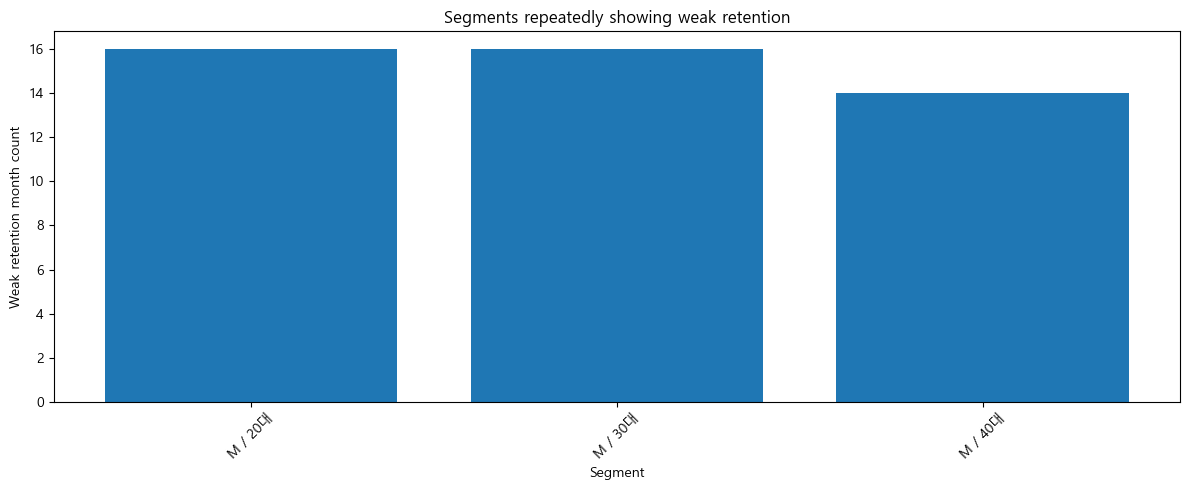

,segment,weak_retention_month_count
0,M / 20대,16
1,M / 30대,16
2,M / 40대,14


In [31]:
weak_count = (
    weak_retention_df
    .groupby("segment")
    .size()
    .reset_index(name="weak_retention_month_count")
    .sort_values("weak_retention_month_count", ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(weak_count["segment"], weak_count["weak_retention_month_count"])
ax.set_title("Segments repeatedly showing weak retention")
ax.set_xlabel("Segment")
ax.set_ylabel("Weak retention month count")
ax.tick_params(axis="x", rotation=45)
save_fig("retention_08_segments_repeatedly_showing_weak_retention.png")
plt.show()

weak_count

In [32]:
real_weak_retention_sql = r"""
-- 7) 실제 Retention 약화 후보
WITH duration AS(
    SELECT month_ym, month_date, gender, age_band, sub_ride_cnt, total_ride_cnt
    FROM mart_growth_month
    UNION ALL
    SELECT 
        month_ym, month_date, gender, age_band, 
        SUM(CASE WHEN pass_group = 'SUBSCRIPTION' THEN ride_cnt ELSE 0 END) AS sub_ride_cnt,
        SUM(ride_cnt) AS total_ride_cnt
    FROM stg_ride_month
    WHERE month_ym = 202312
    GROUP BY month_ym, month_date, gender, age_band
),
segment_month AS (
    SELECT
        month_ym,
        month_date,
        gender,
        age_band,
        SUM(sub_ride_cnt) AS sub_ride_cnt,
        SUM(total_ride_cnt) AS total_ride_cnt
    FROM duration
    WHERE age_band <> '기타'
      AND LOWER(TRIM(COALESCE(gender, ''))) <> 'unknown'
      AND LOWER(TRIM(COALESCE(age_band, ''))) <> 'unknown'
    GROUP BY
        month_ym,
        month_date,
        gender,
        age_band
),
windowed AS (
    SELECT
        month_ym,
        month_date,
        gender,
        age_band,
        sub_ride_cnt,
        total_ride_cnt,
        LAG(sub_ride_cnt) OVER (
            PARTITION BY gender, age_band
            ORDER BY month_ym
        ) AS prev_month_sub_ride_cnt
    FROM segment_month
),
ranked AS (
    SELECT
        *,
        CASE
            WHEN prev_month_sub_ride_cnt > 0
            THEN 1.0 * sub_ride_cnt / prev_month_sub_ride_cnt
            ELSE NULL
        END AS retention_proxy_mom,
        NTILE(4) OVER (
            PARTITION BY month_ym
            ORDER BY sub_ride_cnt
        ) AS sub_ride_volume_quartile_in_month,
        NTILE(4) OVER (
            PARTITION BY month_ym
            ORDER BY CASE
                WHEN prev_month_sub_ride_cnt > 0
                THEN 1.0 * sub_ride_cnt / prev_month_sub_ride_cnt
                ELSE NULL
            END
        ) AS retention_quartile_in_month
    FROM windowed
)
SELECT
    month_ym,
    month_date,
    gender,
    age_band,
    sub_ride_cnt,
    prev_month_sub_ride_cnt,
    ROUND(retention_proxy_mom, 4) AS retention_proxy_mom,
    sub_ride_volume_quartile_in_month,
    retention_quartile_in_month
FROM ranked
WHERE prev_month_sub_ride_cnt IS NOT NULL
  AND sub_ride_volume_quartile_in_month = 4
  AND retention_quartile_in_month <= 2
  AND retention_proxy_mom < 1
ORDER BY
    month_ym,
    sub_ride_cnt DESC;
"""

real_weak_retention_df = read_sql(real_weak_retention_sql)
real_weak_retention_df = add_segment_label(real_weak_retention_df)
real_weak_retention_df

,month_ym,month_date,gender,age_band,sub_ride_cnt,prev_month_sub_ride_cnt,retention_proxy_mom,sub_ride_volume_quartile_in_month,retention_quartile_in_month,segment
0,202401,2024-01-01,M,20대,180470,209964,0.8595,4,1,M / 20대
1,202401,2024-01-01,M,40대,156976,157145,0.9989,4,2,M / 40대
2,202402,2024-02-01,M,30대,212230,221091,0.9599,4,1,M / 30대
3,202402,2024-02-01,M,20대,174563,180470,0.9673,4,1,M / 20대
4,202402,2024-02-01,M,40대,151394,156976,0.9644,4,1,M / 40대
5,202407,2024-07-01,M,30대,385614,469999,0.8205,4,2,M / 30대
6,202407,2024-07-01,M,20대,329011,409661,0.8031,4,2,M / 20대
7,202409,2024-09-01,M,30대,408952,416864,0.9810,4,1,M / 30대
8,202409,2024-09-01,M,40대,287115,287972,0.9970,4,2,M / 40대
9,202411,2024-11-01,M,30대,349648,447679,0.7810,4,2,M / 30대


saved: c:\Users\위동국\Documents\GitHub\seoul-bike-aarrr-analysis\images\retention\retention_09_segments_repeatedly_showing_real_weak_retention.png


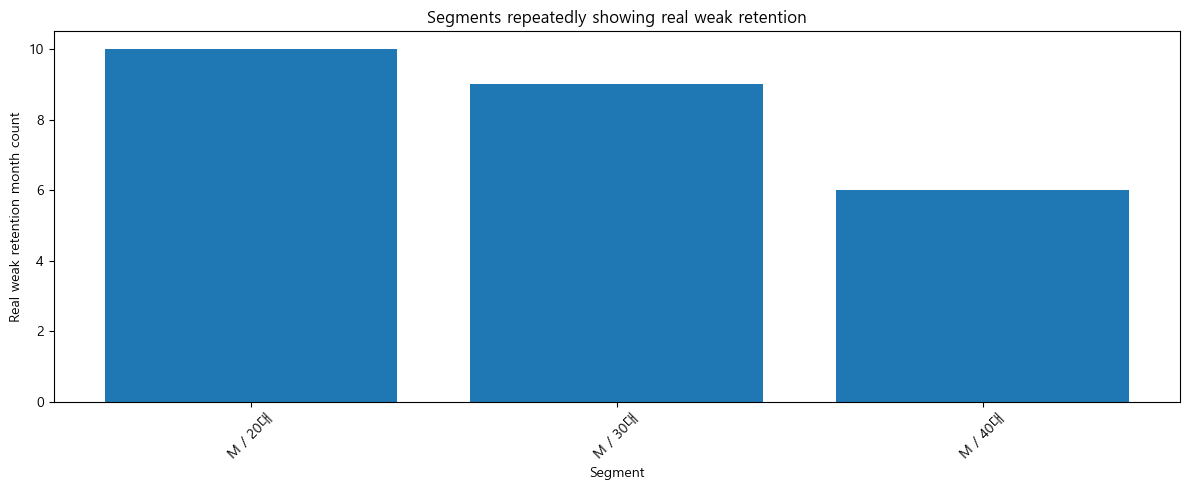

,segment,weak_retention_month_count
0,M / 20대,10
1,M / 30대,9
2,M / 40대,6


In [33]:
real_weak_count = (
    real_weak_retention_df
    .groupby("segment")
    .size()
    .reset_index(name="weak_retention_month_count")
    .sort_values("weak_retention_month_count", ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(real_weak_count["segment"], real_weak_count["weak_retention_month_count"])
ax.set_title("Segments repeatedly showing real weak retention")
ax.set_xlabel("Segment")
ax.set_ylabel("Real weak retention month count")
ax.tick_params(axis="x", rotation=45)
save_fig("retention_09_segments_repeatedly_showing_real_weak_retention.png")
plt.show()

real_weak_count

In [37]:
# Retention 분석 결과 요약 Markdown 저장
from datetime import datetime

summary_path = REPORT_DIR / "retention_analysis_summary.md"

def format_md_value(value):
    if pd.isna(value):
        return ""
    if isinstance(value, float):
        return f"{value:,.4f}".rstrip("0").rstrip(".")
    if isinstance(value, int):
        return f"{value:,}"
    return str(value).replace("|", "\\|")

def df_to_markdown(df: pd.DataFrame, max_rows: int | None = None) -> str:
    display_df = df.head(max_rows).copy() if max_rows else df.copy()
    if display_df.empty:
        return "_결과 없음_"

    columns = list(display_df.columns)
    header = "| " + " | ".join(columns) + " |"
    divider = "| " + " | ".join(["---"] * len(columns)) + " |"
    rows = [
        "| " + " | ".join(format_md_value(row[col]) for col in columns) + " |"
        for _, row in display_df.iterrows()
    ]
    return "\n".join([header, divider, *rows])

monthly_overview = monthly_retention_df.merge(
    monthly_prev3m_df[["month_ym", "rolling_3m_persistence", "current_vs_prev3m_growth_rate"]],
    on="month_ym",
    how="left",
)

best_mom = monthly_retention_df.loc[monthly_retention_df["retention_proxy_mom"].idxmax()]
worst_mom = monthly_retention_df.loc[monthly_retention_df["retention_proxy_mom"].idxmin()]
best_prev3m = monthly_prev3m_df.loc[monthly_prev3m_df["rolling_3m_persistence"].idxmax()]
worst_prev3m = monthly_prev3m_df.loc[monthly_prev3m_df["rolling_3m_persistence"].idxmin()]

strong_segments = segment_summary_df.sort_values(
    ["avg_retention_proxy_mom", "avg_rolling_3m_persistence", "avg_monthly_sub_ride_cnt"],
    ascending=False,
).head(10)

weak_segments = real_weak_count.head(10)
image_files = sorted(path.name for path in IMAGE_DIR.glob("retention_*.png"))
image_list = "\n".join(f"- `images/retention/{name}`" for name in image_files)

report_md = f"""# Retention 분석 결과 요약

생성일: {datetime.now():%Y-%m-%d %H:%M}

## 1. 분석 기준

공개데이터에는 개인 ID가 없으므로 이 분석은 개인 단위 재방문율이 아니라 월별·성별·연령대별 정기권 이용 지속성 proxy로 Retention을 해석한다.

- 전월 대비 정기권 이용 유지율: `retention_proxy_mom = 이번 달 정기권 이용건수 / 전월 정기권 이용건수`
- 최근 3개월 평균 대비 이번 달 정기권 이용: `rolling_3m_persistence = 이번 달 정기권 이용건수 / 직전 3개월 평균 정기권 이용건수`
- 세그먼트 해석 기준: 정기권 이용 규모, 전월 대비 유지율, 최근 3개월 평균 대비 지표를 함께 비교

## 2. 월별 Retention 핵심 흐름

- 전월 대비 Retention proxy가 가장 높았던 월: `{int(best_mom['month_ym'])}` (`{best_mom['retention_proxy_mom']:.4f}`)
- 전월 대비 Retention proxy가 가장 낮았던 월: `{int(worst_mom['month_ym'])}` (`{worst_mom['retention_proxy_mom']:.4f}`)
- 최근 3개월 평균 대비 이용 강도가 가장 높았던 월: `{int(best_prev3m['month_ym'])}` (`{best_prev3m['rolling_3m_persistence']:.4f}`)
- 최근 3개월 평균 대비 이용 강도가 가장 낮았던 월: `{int(worst_prev3m['month_ym'])}` (`{worst_prev3m['rolling_3m_persistence']:.4f}`)

{df_to_markdown(monthly_overview[['month_ym', 'sub_ride_cnt', 'retention_proxy_mom', 'mom_sub_ride_growth_rate', 'rolling_3m_persistence', 'current_vs_prev3m_growth_rate']])}

## 3. 지속이용 강한 세그먼트 TOP 10

{df_to_markdown(strong_segments[['segment', 'avg_monthly_sub_ride_cnt', 'avg_retention_proxy_mom']])}

## 4. Retention 세그먼트 유형 분포

{df_to_markdown(type_count)}

## 5. 실제 Retention 약화 후보

정기권 이용 규모가 월별 상위권이면서 전월 대비 유지율이 낮고, 실제 전월 대비 이용건수도 감소한 세그먼트의 반복 출현 횟수다.

{df_to_markdown(weak_segments)}

## 6. 주요 해석

- Retention은 월별 계절성의 영향을 받으므로 전월 대비 지표와 최근 3개월 평균 대비 지표를 함께 봐야 한다.
- `규모 큼 + 지속이용 강함` 유형은 핵심 유지 세그먼트로 보고, 정기권 혜택·커뮤니케이션의 기준 집단으로 활용할 수 있다.
- 반복적으로 약한 Retention 후보에 등장하는 세그먼트는 이용 규모는 있으나 유지 흐름이 흔들리는 집단이므로 이탈 방어 캠페인 후보로 볼 수 있다.
- 개인 ID가 없는 데이터 한계 때문에 결과는 재방문율이 아니라 정기권 이용량 기반 Retention proxy로 해석해야 한다.

"""

summary_path.write_text(report_md, encoding="utf-8")
print("saved:", summary_path)

saved: c:\Users\위동국\Documents\GitHub\seoul-bike-aarrr-analysis\reports\retention_analysis_summary.md


In [ ]:
conn.close()
print("DB connection closed")